# Pacific Perturbation Experiments with Precipitation Forecasting

This notebook performs systematic perturbation experiments on different areas in the Pacific Ocean with **precipitation forecasting** using Aurora-Lite Decoder.

## Objectives:
1. Apply Gaussian temperature perturbations to gridded points across the Pacific
2. Perform 28-step rollouts starting from 2012-10-24 with precipitation decoder
3. Compare precipitation forecasts between control and perturbed cases
4. Analyze Eastern US rainfall at final forecast step
5. Save comprehensive forecast outputs including precipitation

## Configuration:
- **Start Date**: 2012-10-24 at 06:00 UTC
- **Rollout Steps**: 28 steps (6-hour intervals = 168 hours / 7 days)
- **Perturbation Grid**: Multiple points across the Pacific
- **Precipitation**: Aurora-Lite Decoder for 6-hourly accumulated precipitation

## 1. Setup and Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Set Working Directory

In [ ]:
import sys
import os

# Set working directory to project folder
project_dir = '/content/drive/MyDrive/Research/aurora-lite-decoder-perturbation'
os.chdir(project_dir)

# Add to Python path
if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

print(f"Working directory: {os.getcwd()}")
print(f"Project dir in path: {project_dir in sys.path}")

Working directory: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation
Project dir in path: True


## 3. Install Dependencies and Imports

In [ ]:
%pip install -q flash_attn
%pip install -q cartopy
%pip install -q h5netcdf

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 62.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 97.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
import xarray as xr
from pathlib import Path
from datetime import datetime, timedelta
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from aurora.batch import Batch, Metadata
from aurora.model.aurora_lite import AuroraLite
from aurora.model.decoder_lite import MLPDecoderLite
from aurora.rollout import rollout_with_latents
from transform_data import transform_data

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300

print(f"Using device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


Using device: cuda


In [ ]:
def run_control_simulation(modelAurora, modelDecoder, initial_batch, steps):
    """
    Run normal forecast WITHOUT any perturbation for comparison.

    Returns:
        dict with:
            - 'precip': List of precipitation predictions (meters)
            - 'wind_speed_700': List of wind speed at 700 hPa (m/s)
            - 'times': List of forecast times
            - 'lat', 'lon': Coordinates
    """
    precip_predictions = []
    wind_speed_700_list = []
    times = []

    # Identify 700 hPa pressure level index
    p_levels = list(initial_batch.metadata.atmos_levels)
    if 700 in p_levels:
        idx_700 = p_levels.index(700)
    else:
        idx_700 = 7  # Default

    print(f"Using pressure level index {idx_700} for 700 hPa (levels: {p_levels})")

    with torch.inference_mode():
        for i, (pred_batch, latent) in enumerate(rollout_with_latents(modelAurora, initial_batch, steps)):
            # Decode precipitation
            decoder_out = modelDecoder(
                latent.detach(),
                pred_batch.metadata.lat,
                pred_batch.metadata.lon,
            )

            # Transform back to original scale (meters)
            precip = transform_data(
                decoder_out["tp_mswep"].cpu().numpy().squeeze(),
                "tp_mswep",
                direct=False,
            )
            precip_predictions.append(precip)

            # Extract wind components at 700 hPa
            u_700 = pred_batch.atmos_vars["u"][0, -1, idx_700].cpu().numpy()
            v_700 = pred_batch.atmos_vars["v"][0, -1, idx_700].cpu().numpy()

            # Compute wind speed
            wind_speed_700 = np.sqrt(u_700**2 + v_700**2)
            wind_speed_700_list.append(wind_speed_700)

            # Track times
            forecast_time = np.datetime64(pred_batch.metadata.time[0]) + np.timedelta64(i*6, "h")
            times.append(forecast_time)

            # Free memory
            del decoder_out, latent
            torch.cuda.empty_cache()

    return {
        'precip': precip_predictions,
        'wind_speed_700': wind_speed_700_list,
        'times': times,
        'lat': initial_batch.metadata.lat.cpu().numpy(),
        'lon': initial_batch.metadata.lon.cpu().numpy(),
    }

print("Control simulation function defined.")


Control simulation function defined.


## 4. Configuration

In [ ]:
# ========== PATHS ==========
ERA5_DATA_PATH = Path("/content/drive/MyDrive/Research")
MSWEP_DATA_PATH = "./MSWEP_V280"  # For ground truth validation (optional)
DECODER_CHECKPOINT = "./lite-decoder.ckpt"
OUTPUT_DIR = Path("./pacific_perturbation_precip_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ========== EXPERIMENT CONFIGURATION ==========
START_DATE = "2012-10-24"  # Initial condition date
START_HOUR = 6             # Hour of day (06:00 UTC)
ROLLOUT_STEPS = 28         # Number of 6-hour forecast steps (7 days)

# ========== PERTURBATION GRID ==========
# Define grid of perturbation points in the Pacific

# Option 1: Coarse grid (3x3 = 9 experiments, faster)
# latitudes = np.linspace(10.0, 27.5, 3)   # 3 latitude points
# longitudes = np.linspace(140, 250, 3)    # 3 longitude points

# Option 2: Medium grid (4x4 = 16 experiments)
# latitudes = np.linspace(10.0, 40.0, 4)
# longitudes = np.linspace(130, 250, 4)

# Option 3: Fine grid (5x5 = 25 experiments, takes longer)
latitudes = np.linspace(15.0, 55.0, 5)
longitudes = np.linspace(120, 260, 7)

# Convert longitudes >180 to western hemisphere
longitudes_wrapped = [lon if lon <= 180 else lon - 360 for lon in longitudes]
perturbation_centers = [(lat, lon) for lat in latitudes for lon in longitudes_wrapped]

# ========== PERTURBATION PARAMETERS ==========
Lv = 2.5e6       # Latent heat of vaporization [J/kg]
cp = 1005        # Specific heat at constant pressure [J/kg·K]
delta_q = 0.0010  # Water vapor condensed [kg/kg]
delta_T = (Lv * delta_q) / cp  # Temperature increase ≈ 2.49 K
sigma = 8.0       # Gaussian width (degrees)
amplitude = delta_T
PERTURB_LEVELS_MIN = 700
PERTURB_LEVELS_MAX = 925

# ========== EASTERN US REGION ==========
EASTERN_US_LAT = (25, 70)    # 25°N to 50°N
EASTERN_US_LON = (245, 295)  # 280°E to 295°E (i.e., -80°W to -65°W)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("CONFIGURATION SUMMARY")
print("=" * 70)
print(f"Start date: {START_DATE} {START_HOUR:02d}:00 UTC")
print(f"Rollout steps: {ROLLOUT_STEPS} ({ROLLOUT_STEPS*6} hours / {ROLLOUT_STEPS*6/24:.1f} days)")
print(f"\nPerturbation grid: {len(perturbation_centers)} experiments")
print(f"  Latitude range: {latitudes.min():.1f}° to {latitudes.max():.1f}°")
print(f"  Longitude range: {longitudes.min():.1f}° to {longitudes.max():.1f}°")
print(f"\nPerturbation parameters:")
print(f"  Temperature amplitude: {amplitude:.2f} K")
print(f"  Gaussian width: {sigma:.1f}°")
print(f"  Vertical extent: {PERTURB_LEVELS_MIN}-{PERTURB_LEVELS_MAX} hPa")
print(f"\nEastern US region:")
print(f"  Latitude: {EASTERN_US_LAT[0]}°N to {EASTERN_US_LAT[1]}°N")
print(f"  Longitude: {EASTERN_US_LON[0]-360}°W to {EASTERN_US_LON[1]-360}°W")
print(f"\nOutput directory: {OUTPUT_DIR}")
print(f"Device: {device}")
print("=" * 70)

CONFIGURATION SUMMARY
Start date: 2012-10-24 06:00 UTC
Rollout steps: 28 (168 hours / 7.0 days)

Perturbation grid: 35 experiments
  Latitude range: 15.0° to 55.0°
  Longitude range: 120.0° to 260.0°

Perturbation parameters:
  Temperature amplitude: 2.49 K
  Gaussian width: 8.0°
  Vertical extent: 700-925 hPa

Eastern US region:
  Latitude: 25°N to 70°N
  Longitude: -115°W to -65°W

Output directory: pacific_perturbation_precip_outputs
Device: cuda


## 5. Load ERA5 Data Function

In [ ]:
def load_era5_batch(date_str, hour, era5_path):
    """
    Load ERA5 data for a specific date and hour to create Aurora batch.
    """
    era5_path = Path(era5_path)
    date = pd.to_datetime(date_str)

    # Load static variables
    static_vars_ds = xr.open_dataset(era5_path / "static.nc", engine="h5netcdf")
    static_vars_ds = static_vars_ds.sel(latitude=static_vars_ds.latitude[:720])

    # Load surface variables
    surf_file = era5_path / f"{date_str}-surface-level.nc"
    if not surf_file.exists():
        raise FileNotFoundError(f"Surface data not found: {surf_file}")
    surf_vars_ds = xr.open_dataset(surf_file, engine="h5netcdf")
    surf_vars_ds = surf_vars_ds.sel(latitude=surf_vars_ds.latitude[:720])

    # Load atmospheric variables
    atmos_file = era5_path / f"{date_str}-atmospheric.nc"
    if not atmos_file.exists():
        raise FileNotFoundError(f"Atmospheric data not found: {atmos_file}")
    atmos_vars_ds = xr.open_dataset(atmos_file, engine="h5netcdf")
    atmos_vars_ds = atmos_vars_ds.sel(latitude=atmos_vars_ds.latitude[:720])

    # Find time index
    time_idx = hour // 6

    # Create batch
    batch = Batch(
        surf_vars={
            "2t": torch.from_numpy(surf_vars_ds["t2m"].values[time_idx:time_idx+2][None]),
            "10u": torch.from_numpy(surf_vars_ds["u10"].values[time_idx:time_idx+2][None]),
            "10v": torch.from_numpy(surf_vars_ds["v10"].values[time_idx:time_idx+2][None]),
            "msl": torch.from_numpy(surf_vars_ds["msl"].values[time_idx:time_idx+2][None]),
        },
        static_vars={
            "z": torch.from_numpy(static_vars_ds["z"].values[0]),
            "slt": torch.from_numpy(static_vars_ds["slt"].values[0]),
            "lsm": torch.from_numpy(static_vars_ds["lsm"].values[0]),
        },
        atmos_vars={
            "t": torch.from_numpy(atmos_vars_ds["t"].values[time_idx:time_idx+2][None]),
            "u": torch.from_numpy(atmos_vars_ds["u"].values[time_idx:time_idx+2][None]),
            "v": torch.from_numpy(atmos_vars_ds["v"].values[time_idx:time_idx+2][None]),
            "q": torch.from_numpy(atmos_vars_ds["q"].values[time_idx:time_idx+2][None]),
            "z": torch.from_numpy(atmos_vars_ds["z"].values[time_idx:time_idx+2][None]),
        },
        metadata=Metadata(
            lat=torch.from_numpy(surf_vars_ds.latitude.values),
            lon=torch.from_numpy(surf_vars_ds.longitude.values),
            time=(surf_vars_ds.valid_time.values.astype("datetime64[s]").tolist()[time_idx+1],),
            atmos_levels=tuple(int(level) for level in atmos_vars_ds.pressure_level.values),
        ),
    )

    return batch

print("ERA5 loading function defined.")

ERA5 loading function defined.


## 6. Perturbation Function

In [ ]:
def make_perturbed_batch(batch_orig, center_lat, center_lon, amplitude=delta_T, sigma=8.0):
    """
    Create a perturbed batch with Gaussian temperature anomaly.
    """
    lon = batch_orig.metadata.lon.cpu().numpy()
    lat = batch_orig.metadata.lat.cpu().numpy()

    if lon.max() > 180:
        center_lon = (center_lon + 360) % 360

    lon_grid, lat_grid = np.meshgrid(lon, lat)
    dlon = (lon_grid - center_lon + 180) % 360 - 180
    dlat = lat_grid - center_lat

    gaussian_mask = amplitude * np.exp(-(dlon**2 + dlat**2) / (2 * sigma**2))
    gaussian_mask_torch = torch.from_numpy(gaussian_mask).float().to(batch_orig.atmos_vars["t"].device)

    # Clone all variables
    new_surf_vars = {k: v.clone() for k, v in batch_orig.surf_vars.items()}
    new_atmos_vars = {k: v.clone() for k, v in batch_orig.atmos_vars.items()}

    # Find pressure levels to perturb
    p_levels = torch.tensor(batch_orig.metadata.atmos_levels)
    plev_idx = torch.where((p_levels >= PERTURB_LEVELS_MIN) & (p_levels <= PERTURB_LEVELS_MAX))[0]

    # Apply perturbation to all timesteps at specified levels
    for i in plev_idx:
        for t in range(new_atmos_vars['t'].shape[1]):
            new_atmos_vars['t'][0, t, i, :, :] += gaussian_mask_torch

    return Batch(
        surf_vars=new_surf_vars,
        static_vars=batch_orig.static_vars,
        atmos_vars=new_atmos_vars,
        metadata=batch_orig.metadata,
    )

print("Perturbation function defined.")


Perturbation function defined.


## 7. Forecasting with Decoder

In [ ]:
def forecast_with_decoder(modelAurora, modelDecoder, initial_batch, steps):
    """
    Perform multi-step forecasting with precipitation decoder.

    Returns:
        dict with:
            - 'precip': List of precipitation predictions (meters)
            - 'times': List of forecast times
            - 'lat', 'lon': Coordinates
    """
    precip_predictions = []
    times = []

    with torch.inference_mode():
        for i, (pred_batch, latent) in enumerate(rollout_with_latents(modelAurora, initial_batch, steps)):
            # Decode precipitation
            decoder_out = modelDecoder(
                latent.detach(),
                pred_batch.metadata.lat,
                pred_batch.metadata.lon,
            )

            # Transform back to original scale (meters)
            precip = transform_data(
                decoder_out["tp_mswep"].cpu().numpy().squeeze(),
                "tp_mswep",
                direct=False,
            )
            precip_predictions.append(precip)

            # Track times
            forecast_time = np.datetime64(pred_batch.metadata.time[0]) + np.timedelta64(i*6, "h")
            times.append(forecast_time)

            # Free memory
            del decoder_out, latent
            torch.cuda.empty_cache()

    return {
        'precip': precip_predictions,
        'times': times,
        'lat': initial_batch.metadata.lat.cpu().numpy(),
        'lon': initial_batch.metadata.lon.cpu().numpy(),
    }

print("Forecast function with decoder defined.")

Forecast function with decoder defined.


## 8. Save Functions

In [ ]:
def save_precipitation_netcdf(precip_list, times, lat, lon, save_path, metadata=None):
    """
    Save precipitation forecasts to NetCDF file.

    Args:
        precip_list: List of 2D precipitation arrays (meters)
        times: List of datetime64 objects
        lat, lon: Coordinate arrays
        save_path: Output file path
        metadata: Optional dict of metadata to add as attributes
    """
    # Stack precipitation into 3D array
    precip_3d = np.stack(precip_list, axis=0)  # [time, lat, lon]

    # Create dataset
    ds = xr.Dataset(
        {
            "precipitation": (["time", "lat", "lon"], precip_3d),
        },
        coords={
            "time": times,
            "lat": lat,
            "lon": lon,
        },
    )

    # Add metadata
    ds.attrs["description"] = "Aurora-Lite precipitation forecast with perturbation"
    ds.attrs["units"] = "meters (6-hourly accumulation)"
    ds.attrs["created"] = str(datetime.now())

    if metadata:
        for key, value in metadata.items():
            ds.attrs[key] = value

    # Save
    ds.to_netcdf(save_path)

print("Save function defined.")

Save function defined.


## 9. Load Models

In [ ]:
print("Loading Aurora-Lite model...")

# Initialize Aurora model
modelAurora = AuroraLite(
    use_lora=False,
    autocast=True,
    surf_vars=("2t", "10u", "10v", "msl"),
    static_vars=("lsm", "z", "slt"),
    atmos_vars=("z", "u", "v", "t", "q")
)

modelAurora.load_checkpoint("microsoft/aurora", "aurora-0.25-pretrained.ckpt")
modelAurora = modelAurora.to(device)
modelAurora.eval()

print("✓ Aurora model loaded")

# Load decoder model
print("Loading decoder model...")

surf_vars_new = ["tp_mswep", "pe", "r", "swc"]
modelDecoder = MLPDecoderLite(
    surf_vars_new=surf_vars_new,
    patch_size=modelAurora.decoder.patch_size,
    embed_dim=2*modelAurora.encoder.embed_dim,
    hidden_dims=[512, 512, 256],
)

checkpoint = torch.load(DECODER_CHECKPOINT, map_location=device)
modelDecoder.load_state_dict(checkpoint)
modelDecoder.to(device)
modelDecoder.eval()

print("✓ Decoder model loaded")
print("\n✓ All models ready!")

Loading Aurora-Lite model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


aurora-0.25-pretrained.ckpt:   0%|          | 0.00/5.03G [00:00<?, ?B/s]

✓ Aurora model loaded
Loading decoder model...
✓ Decoder model loaded

✓ All models ready!


## 10. Load Initial Conditions

In [ ]:
print(f"Loading ERA5 initial conditions for {START_DATE} {START_HOUR:02d}:00 UTC...")
batch_orig = load_era5_batch(START_DATE, START_HOUR, ERA5_DATA_PATH)
print(f"✓ Loaded ERA5 data")
print(f"  Initial time: {batch_orig.metadata.time[0]}")
print(f"  Grid: {len(batch_orig.metadata.lat)} lat × {len(batch_orig.metadata.lon)} lon")

Loading ERA5 initial conditions for 2012-10-24 06:00 UTC...
✓ Loaded ERA5 data
  Initial time: 2012-10-24 12:00:00
  Grid: 720 lat × 1440 lon


## 11. Run Control Experiment

In [ ]:
print("\nRunning control experiment (no perturbation)...")

results_control = forecast_with_decoder(modelAurora, modelDecoder, batch_orig, ROLLOUT_STEPS)

print(f"✓ Control forecast complete: {len(results_control['precip'])} steps")

# Save control forecast
save_precipitation_netcdf(
    results_control['precip'],
    results_control['times'],
    results_control['lat'],
    results_control['lon'],
    OUTPUT_DIR / "control_precipitation.nc",
    metadata={
        'experiment': 'control',
        'start_date': START_DATE,
        'perturbation': 'none'
    }
)

print(f"✓ Saved: {OUTPUT_DIR / 'control_precipitation.nc'}")


Running control experiment (no perturbation)...
✓ Control forecast complete: 28 steps
✓ Saved: pacific_perturbation_precip_outputs/control_precipitation.nc


## 12. Run Perturbation Experiments

In [ ]:
print(f"\n{'='*70}")
print(f"Running {len(perturbation_centers)} perturbation experiments")
print(f"{'='*70}\n")

# Storage for results
all_results = []

for i, (clat, clon) in enumerate(perturbation_centers):
    print(f"[{i+1}/{len(perturbation_centers)}] Perturbation at ({clat:.2f}°, {clon:.2f}°)")

    # Create perturbed batch
    batch_pert = make_perturbed_batch(batch_orig, clat, clon)
    torch.cuda.empty_cache()

    # Run forecast
    results = forecast_with_decoder(modelAurora, modelDecoder, batch_pert, ROLLOUT_STEPS)

    # Save forecast
    output_file = OUTPUT_DIR / f"perturb_{i:03d}_lat{clat:.1f}_lon{clon:.1f}_precip.nc"
    save_precipitation_netcdf(
        results['precip'],
        results['times'],
        results['lat'],
        results['lon'],
        output_file,
        metadata={
            'experiment_id': i,
            'perturbation_center_lat': clat,
            'perturbation_center_lon': clon,
            'perturbation_amplitude': amplitude,
            'perturbation_sigma': sigma,
        }
    )

    # Store summary info
    final_precip = results['precip'][-1]  # Final timestep
    all_results.append({
        'experiment_id': i,
        'center_lat': clat,
        'center_lon': clon,
        'mean_precip_final': float(final_precip.mean() * 1000),  # mm
        'max_precip_final': float(final_precip.max() * 1000),
        'output_file': output_file.name,
    })

    print(f"  ✓ Saved: {output_file.name}")
    print(f"    Final precip - Mean: {all_results[-1]['mean_precip_final']:.3f} mm, Max: {all_results[-1]['max_precip_final']:.2f} mm")
    print()

print(f"{'='*70}")
print(f"✓ All {len(perturbation_centers)} perturbation experiments complete!")
print(f"{'='*70}")


Running 35 perturbation experiments

[1/35] Perturbation at (15.00°, 120.00°)
  ✓ Saved: perturb_000_lat15.0_lon120.0_precip.nc
    Final precip - Mean: 0.434 mm, Max: 48.60 mm

[2/35] Perturbation at (15.00°, 143.33°)
  ✓ Saved: perturb_001_lat15.0_lon143.3_precip.nc
    Final precip - Mean: 0.437 mm, Max: 56.90 mm

[3/35] Perturbation at (15.00°, 166.67°)
  ✓ Saved: perturb_002_lat15.0_lon166.7_precip.nc
    Final precip - Mean: 0.434 mm, Max: 57.40 mm

[4/35] Perturbation at (15.00°, -170.00°)


KeyboardInterrupt: 

## 13. Save Experiment Summary

In [ ]:
# Save summary CSV
summary_df = pd.DataFrame(all_results)
summary_df.to_csv(OUTPUT_DIR / "experiment_summary.csv", index=False)

print("\nExperiment Summary:")
print(summary_df.to_string(index=False))
print(f"\n✓ Summary saved to: {OUTPUT_DIR / 'experiment_summary.csv'}")


Experiment Summary:
 experiment_id  center_lat  center_lon  mean_precip_final  max_precip_final                             output_file
             0        15.0  120.000000           0.433503         48.598602  perturb_000_lat15.0_lon120.0_precip.nc
             1        15.0  143.333333           0.437075         56.897694  perturb_001_lat15.0_lon143.3_precip.nc
             2        15.0  166.666667           0.434360         57.399567  perturb_002_lat15.0_lon166.7_precip.nc
             3        15.0 -170.000000           0.435953         56.104988 perturb_003_lat15.0_lon-170.0_precip.nc
             4        15.0 -146.666667           0.437626         58.044060 perturb_004_lat15.0_lon-146.7_precip.nc
             5        15.0 -123.333333           0.436634         56.626003 perturb_005_lat15.0_lon-123.3_precip.nc
             6        15.0 -100.000000           0.436220         57.392509 perturb_006_lat15.0_lon-100.0_precip.nc
             7        25.0  120.000000           0.

## 14. Eastern US Precipitation Comparison

Compare final timestep precipitation over Eastern US for all experiments

In [ ]:
print("\n" + "="*70)
print("EASTERN US PRECIPITATION ANALYSIS (Final Timestep)")
print("="*70)

# Get coordinates
lat = results_control['lat']
lon = results_control['lon']

# Find Eastern US indices
lat_mask = (lat >= EASTERN_US_LAT[0]) & (lat <= EASTERN_US_LAT[1])
lon_mask = (lon >= EASTERN_US_LON[0]) & (lon <= EASTERN_US_LON[1])
lat_idx = np.where(lat_mask)[0]
lon_idx = np.where(lon_mask)[0]

# Extract control Eastern US precipitation (final step)
precip_control_eus = results_control['precip'][-1][np.ix_(lat_idx, lon_idx)] * 1000  # Convert to mm

print(f"\nRegion: {EASTERN_US_LAT[0]}°N-{EASTERN_US_LAT[1]}°N, {EASTERN_US_LON[0]-360}°W-{EASTERN_US_LON[1]-360}°W")
print(f"Grid size: {len(lat_idx)} × {len(lon_idx)} points")
print(f"\nControl (no perturbation):")
print(f"  Mean: {precip_control_eus.mean():.3f} mm/6h")
print(f"  Max: {precip_control_eus.max():.2f} mm/6h")
print(f"  Total: {precip_control_eus.sum():.1f} mm (grid total)")

# Load and compare all perturbation experiments
print(f"\nPerturbation experiments:")
print("-" * 70)

eus_comparison = []

for result in all_results:
    # Load the netcdf file
    ds = xr.open_dataset(OUTPUT_DIR / result['output_file'])
    precip_pert = ds.precipitation.values[-1]  # Final timestep

    # Extract Eastern US
    precip_pert_eus = precip_pert[np.ix_(lat_idx, lon_idx)] * 1000  # mm

    # Calculate differences
    diff = precip_pert_eus - precip_control_eus

    eus_comparison.append({
        'experiment_id': result['experiment_id'],
        'center_lat': result['center_lat'],
        'center_lon': result['center_lon'],
        'eus_mean': precip_pert_eus.mean(),
        'eus_max': precip_pert_eus.max(),
        'eus_total': precip_pert_eus.sum(),
        'diff_mean': diff.mean(),
        'diff_max': diff.max(),
        'diff_min': diff.min(),
    })

    print(f"Exp {result['experiment_id']:2d} ({result['center_lat']:5.1f}°, {result['center_lon']:6.1f}°): "
          f"Mean={precip_pert_eus.mean():6.3f} mm, "
          f"Δ={diff.mean():+6.3f} mm")

# Save Eastern US comparison
eus_df = pd.DataFrame(eus_comparison)
eus_df.to_csv(OUTPUT_DIR / "eastern_us_comparison.csv", index=False)

print("-" * 70)
print(f"\n✓ Eastern US comparison saved to: {OUTPUT_DIR / 'eastern_us_comparison.csv'}")


EASTERN US PRECIPITATION ANALYSIS (Final Timestep)

Region: 25°N-50°N, -80°W--65°W
Grid size: 101 × 61 points

Control (no perturbation):
  Mean: 1.009 mm/6h
  Max: 11.38 mm/6h
  Total: 6215.1 mm (grid total)

Perturbation experiments:
----------------------------------------------------------------------
Exp  0 ( 15.0°,  120.0°): Mean= 1.007 mm, Δ=-0.002 mm
Exp  1 ( 15.0°,  143.3°): Mean= 1.014 mm, Δ=+0.005 mm
Exp  2 ( 15.0°,  166.7°): Mean= 1.019 mm, Δ=+0.010 mm
Exp  3 ( 15.0°, -170.0°): Mean= 1.005 mm, Δ=-0.004 mm
Exp  4 ( 15.0°, -146.7°): Mean= 0.993 mm, Δ=-0.015 mm
Exp  5 ( 15.0°, -123.3°): Mean= 0.992 mm, Δ=-0.017 mm
Exp  6 ( 15.0°, -100.0°): Mean= 0.977 mm, Δ=-0.032 mm
Exp  7 ( 25.0°,  120.0°): Mean= 1.017 mm, Δ=+0.008 mm
Exp  8 ( 25.0°,  143.3°): Mean= 0.996 mm, Δ=-0.013 mm
Exp  9 ( 25.0°,  166.7°): Mean= 1.012 mm, Δ=+0.003 mm
Exp 10 ( 25.0°, -170.0°): Mean= 0.996 mm, Δ=-0.013 mm
Exp 11 ( 25.0°, -146.7°): Mean= 0.997 mm, Δ=-0.011 mm
Exp 12 ( 25.0°, -123.3°): Mean= 1.010 mm, Δ=

## 15. Visualize Eastern US Comparison

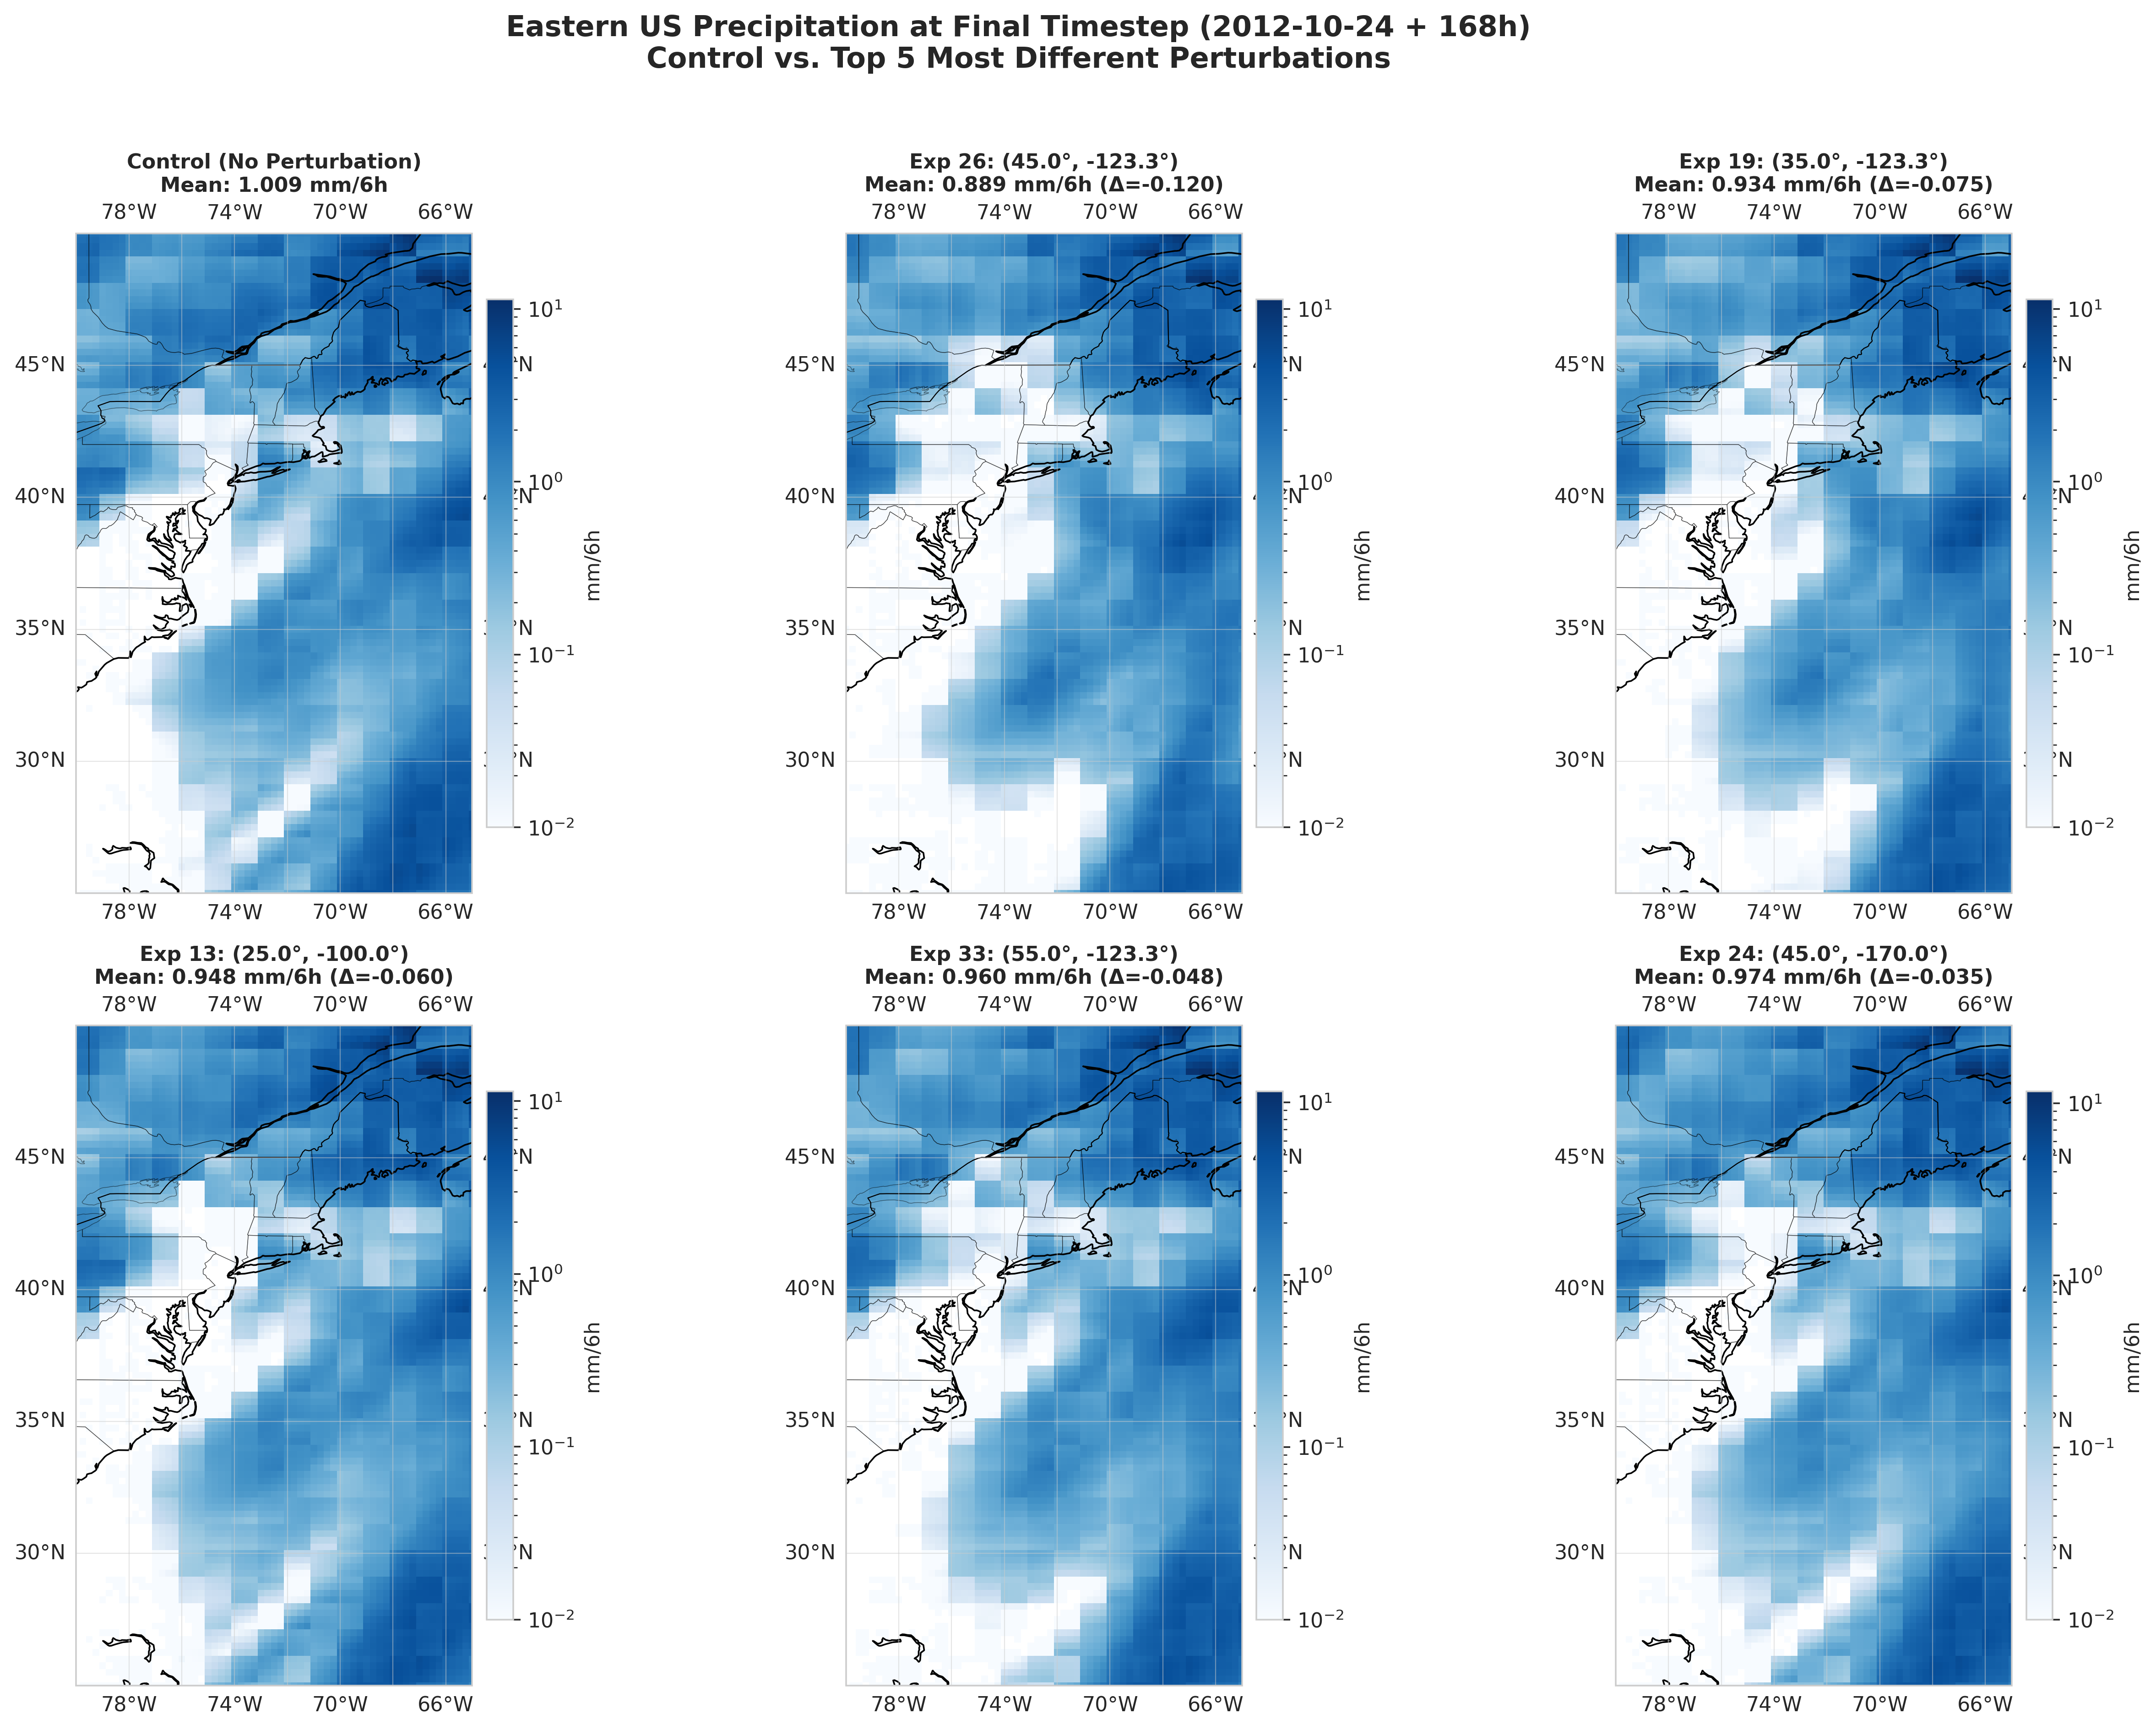


✓ Visualization saved: pacific_perturbation_precip_outputs/eastern_us_comparison.png


In [ ]:
# Create visualization of Eastern US precipitation differences
fig = plt.figure(figsize=(16, 12))
projection = ccrs.PlateCarree()

# Get Eastern US coordinates
lat_eus = lat[lat_idx]
lon_eus = lon[lon_idx]

# Plot control + 4 most different cases
eus_df_sorted = eus_df.sort_values('diff_mean', key=abs, ascending=False)
experiments_to_plot = [None] + list(eus_df_sorted.head(5)['experiment_id'].values)  # None = control

for idx, exp_id in enumerate(experiments_to_plot):
    ax = fig.add_subplot(2, 3, idx + 1, projection=projection)

    if exp_id is None:
        # Control
        precip_plot = precip_control_eus
        title = f"Control (No Perturbation)\nMean: {precip_control_eus.mean():.3f} mm/6h"
    else:
        # Perturbation experiment
        ds = xr.open_dataset(OUTPUT_DIR / all_results[exp_id]['output_file'])
        precip_full = ds.precipitation.values[-1] * 1000
        precip_plot = precip_full[np.ix_(lat_idx, lon_idx)]
        diff_mean = precip_plot.mean() - precip_control_eus.mean()

        title = (f"Exp {exp_id}: ({all_results[exp_id]['center_lat']:.1f}°, "
                f"{all_results[exp_id]['center_lon']:.1f}°)\n"
                f"Mean: {precip_plot.mean():.3f} mm/6h (Δ={diff_mean:+.3f})")

    # Plot
    vmax = max(precip_control_eus.max(), precip_plot.max(), 0.1)
    im = ax.pcolormesh(lon_eus, lat_eus, precip_plot,
                       cmap='Blues',
                       norm=LogNorm(vmin=0.01, vmax=vmax),
                       transform=projection)

    ax.coastlines(linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.3, alpha=0.5)
    ax.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                linewidth=0.5, alpha=0.5)
    ax.set_extent([EASTERN_US_LON[0], EASTERN_US_LON[1],
                   EASTERN_US_LAT[0], EASTERN_US_LAT[1]], crs=projection)
    ax.set_title(title, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.8, label='mm/6h', pad=0.02)

fig.suptitle(f'Eastern US Precipitation at Final Timestep ({START_DATE} + {ROLLOUT_STEPS*6}h)\n'
            f'Control vs. Top 5 Most Different Perturbations',
            fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUTPUT_DIR / 'eastern_us_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Visualization saved: {OUTPUT_DIR / 'eastern_us_comparison.png'}")

## 16. Perturbation Locations Map

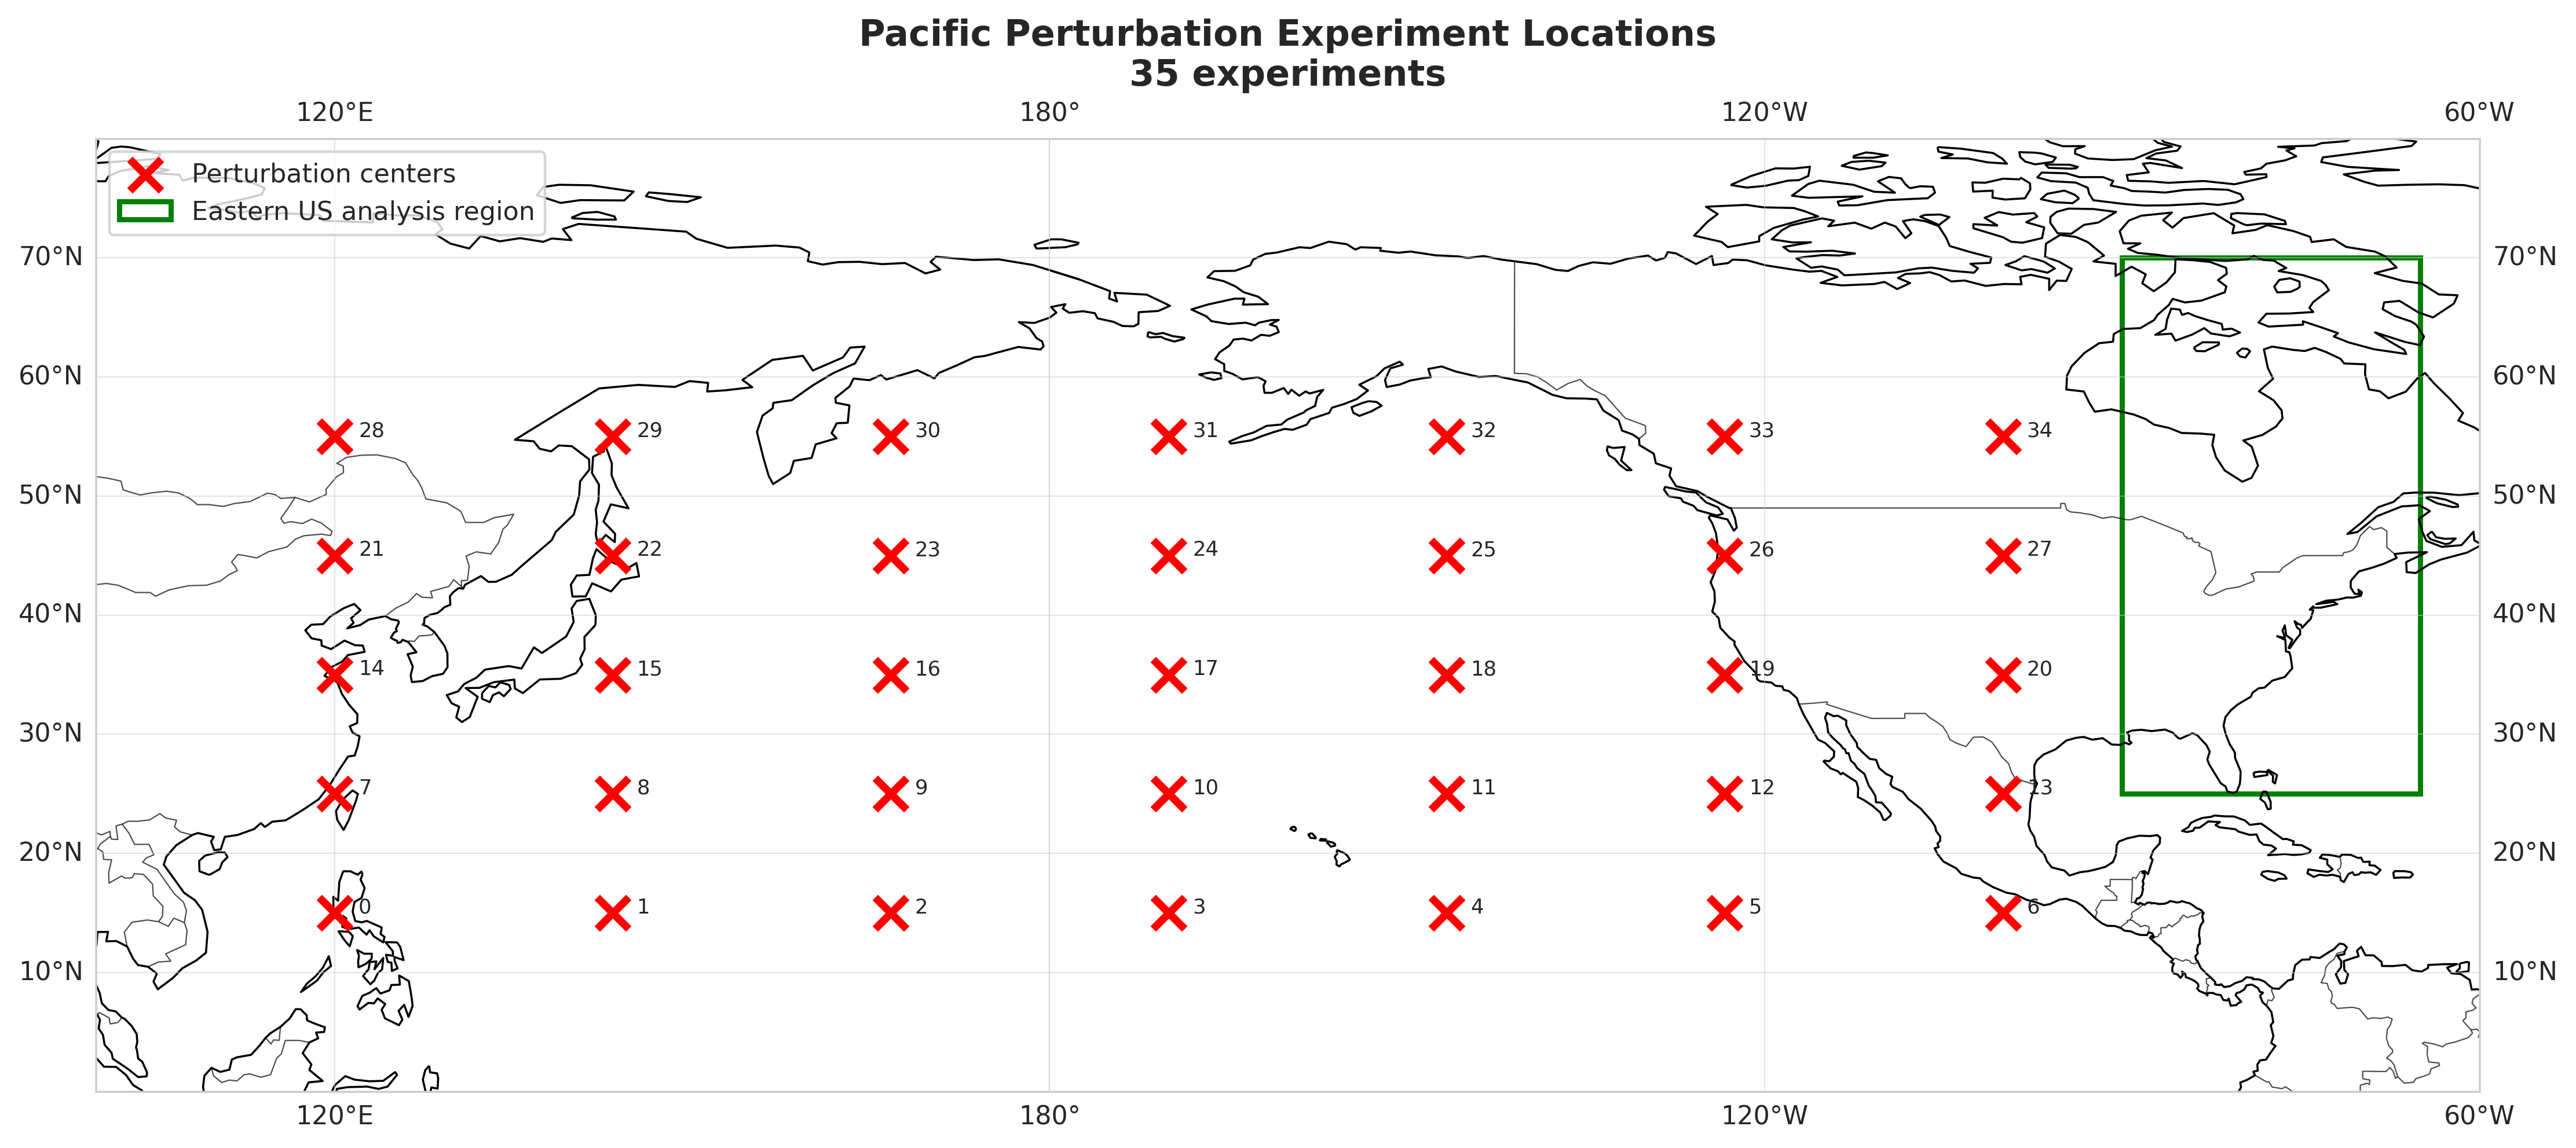

✓ Map saved: pacific_perturbation_precip_outputs/perturbation_locations_map.png


In [ ]:
# Plot perturbation locations on a map
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))

# Plot perturbation centers
lats_plot = [c[0] for c in perturbation_centers]
lons_plot = [c[1] for c in perturbation_centers]

ax.scatter(lons_plot, lats_plot, c='red', s=150, marker='x', linewidths=3,
          label='Perturbation centers', zorder=5, transform=ccrs.PlateCarree())

# Add labels
for i, (lat, lon) in enumerate(perturbation_centers):
    ax.text(lon+2, lat, f'{i}', fontsize=8, transform=ccrs.PlateCarree())

# Add map features
ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.7)
ax.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
            linewidth=0.5, alpha=0.5)

# Highlight Eastern US region
import matplotlib.patches as mpatches
rect = mpatches.Rectangle((EASTERN_US_LON[0], EASTERN_US_LAT[0]),
                          EASTERN_US_LON[1]-EASTERN_US_LON[0],
                          EASTERN_US_LAT[1]-EASTERN_US_LAT[0],
                          linewidth=2, edgecolor='green', facecolor='none',
                          label='Eastern US analysis region',
                          transform=ccrs.PlateCarree())
ax.add_patch(rect)

ax.set_extent([100, 300, 0, 80], crs=ccrs.PlateCarree())
ax.legend(fontsize=10, loc='upper left')
ax.set_title(f'Pacific Perturbation Experiment Locations\n{len(perturbation_centers)} experiments',
            fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'perturbation_locations_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Map saved: {OUTPUT_DIR / 'perturbation_locations_map.png'}")

## 17. Final Summary

In [ ]:
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\nConfiguration:")
print(f"  Start: {START_DATE} {START_HOUR:02d}:00 UTC")
print(f"  Forecast: {ROLLOUT_STEPS} steps ({ROLLOUT_STEPS*6} hours / {ROLLOUT_STEPS*6/24:.1f} days)")
print(f"  Perturbations: {len(perturbation_centers)} experiments")
print(f"\nOutputs in: {OUTPUT_DIR}")
print(f"\nFiles generated:")
print(f"  • control_precipitation.nc")
print(f"  • perturb_XXX_latYY.Y_lonZZZ.Z_precip.nc ({len(perturbation_centers)} files)")
print(f"  • experiment_summary.csv")
print(f"  • eastern_us_comparison.csv")
print(f"  • eastern_us_comparison.png")
print(f"  • perturbation_locations_map.png")
print(f"\nEastern US Analysis:")
print(f"  Control mean: {precip_control_eus.mean():.3f} mm/6h")
print(f"  Range of perturbation impacts: {eus_df['diff_mean'].min():+.3f} to {eus_df['diff_mean'].max():+.3f} mm/6h")
print(f"  Largest impact: Exp {eus_df.loc[eus_df['diff_mean'].abs().idxmax(), 'experiment_id']}")
print("\n" + "="*70)
print("✓ ALL EXPERIMENTS COMPLETE!")
print("="*70)


FINAL SUMMARY

Configuration:
  Start: 2012-10-24 06:00 UTC
  Forecast: 28 steps (168 hours / 7.0 days)
  Perturbations: 35 experiments

Outputs in: pacific_perturbation_precip_outputs

Files generated:
  • control_precipitation.nc
  • perturb_XXX_latYY.Y_lonZZZ.Z_precip.nc (35 files)
  • experiment_summary.csv
  • eastern_us_comparison.csv
  • eastern_us_comparison.png
  • perturbation_locations_map.png

Eastern US Analysis:
  Control mean: 1.009 mm/6h
  Range of perturbation impacts: -0.120 to +0.033 mm/6h
  Largest impact: Exp 26

✓ ALL EXPERIMENTS COMPLETE!


## Next Steps

### Analysis Suggestions:

1. **Time Evolution**: Track how precipitation signals propagate from Pacific to Eastern US
2. **Sensitivity Analysis**: Identify which perturbation locations have strongest Eastern US impact
3. **Statistical Comparison**: Calculate correlation between perturbation location and EUS rainfall change
4. **Atmospheric Pathways**: Analyze 700 hPa winds to understand teleconnection patterns
5. **MSWEP Validation**: Load MSWEP ground truth for verification (if available)

### Example Follow-up Code:

```python
# Load results
ds_control = xr.open_dataset(OUTPUT_DIR / "control_precipitation.nc")
ds_pert = xr.open_dataset(OUTPUT_DIR / "perturb_000_lat10.0_lon140.0_precip.nc")

# Calculate time series of Eastern US mean precipitation
eus_ts_control = ds_control.precipitation.sel(
    lat=slice(EASTERN_US_LAT[0], EASTERN_US_LAT[1]),
    lon=slice(EASTERN_US_LON[0], EASTERN_US_LON[1])
).mean(dim=['lat', 'lon'])

# Plot evolution
eus_ts_control.plot(label='Control')
```

## 18. Comparison Plots: All Perturbations + Control

Create comparison plots for Eastern US and entire US showing all experiments

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path

# Load control data
ds_control = xr.open_dataset(OUTPUT_DIR / "control_precipitation.nc")
lat = ds_control.lat.values
lon = ds_control.lon.values
precip_control_final = ds_control.precipitation.values[-1] * 1000  # Convert to mm

# Define regions (fixing longitude coordinates)
# Eastern US: 25-50°N, 280-295°E (which is -80 to -65°W)
eastern_us_lat_range = (10, 85)
eastern_us_lon_range = (260, 295)

# Entire US: 25-50°N, 235-295°E (which is -125 to -65°W)
entire_us_lat_range = (10, 85)
entire_us_lon_range = (150, 295)

# Extract regional masks
def get_regional_data(precip_data, lat, lon, lat_range, lon_range):
    """Extract precipitation data for a specific region"""
    lat_mask = (lat >= lat_range[0]) & (lat <= lat_range[1])
    lon_mask = (lon >= lon_range[0]) & (lon <= lon_range[1])

    lat_idx = np.where(lat_mask)[0]
    lon_idx = np.where(lon_mask)[0]

    # Create meshgrid for 2D slicing
    regional_data = precip_data[np.ix_(lat_idx, lon_idx)]
    regional_lat = lat[lat_idx]
    regional_lon = lon[lon_idx]

    return regional_data, regional_lat, regional_lon

# Extract Eastern US control data
eus_control, eus_lat, eus_lon = get_regional_data(
    precip_control_final, lat, lon, eastern_us_lat_range, eastern_us_lon_range
)

# Extract Entire US control data
us_control, us_lat, us_lon = get_regional_data(
    precip_control_final, lat, lon, entire_us_lat_range, entire_us_lon_range
)

print(f"Eastern US grid: {eus_control.shape} ({len(eus_lat)} lat × {len(eus_lon)} lon)")
print(f"Entire US grid: {us_control.shape} ({len(us_lat)} lat × {len(us_lon)} lon)")
print(f"\nEastern US Control - Mean: {eus_control.mean():.3f} mm, Max: {eus_control.max():.2f} mm")
print(f"Entire US Control - Mean: {us_control.mean():.3f} mm, Max: {us_control.max():.2f} mm")

Eastern US grid: (301, 141) (301 lat × 141 lon)
Entire US grid: (301, 581) (301 lat × 581 lon)

Eastern US Control - Mean: 0.429 mm, Max: 11.38 mm
Entire US Control - Mean: 0.468 mm, Max: 39.69 mm


In [ ]:
# Entire US Comparison: All Perturbations + Control
print("\nCreating Entire US comparison plot (all 35 perturbations + control)...")

fig = plt.figure(figsize=(24, 4 * n_rows))

# Plot control first
ax = fig.add_subplot(n_rows, n_cols, 1, projection=ccrs.PlateCarree(central_longitude=180))
vmax_us = us_control.max() if us_control.max() > 0.1 else 1.0
im = ax.pcolormesh(us_lon, us_lat, us_control,
                   cmap='Blues', norm=LogNorm(vmin=0.01, vmax=vmax_us),
                   transform=ccrs.PlateCarree())
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.STATES, linewidth=0.2, alpha=0.5)
ax.set_extent([us_lon.min(), us_lon.max(), us_lat.min(), us_lat.max()],
              crs=ccrs.PlateCarree())
ax.set_title(f'Control\nMean: {us_control.mean():.3f} mm', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

# Plot all perturbations
for i, result in enumerate(all_results):
    ax = fig.add_subplot(n_rows, n_cols, i + 2, projection=ccrs.PlateCarree(central_longitude=180))

    # Load perturbation data
    ds_pert = xr.open_dataset(OUTPUT_DIR / result['output_file'])
    precip_pert_final = ds_pert.precipitation.values[-1] * 1000

    # Extract Entire US region
    us_pert, _, _ = get_regional_data(
        precip_pert_final, lat, lon, entire_us_lat_range, entire_us_lon_range
    )

    # Calculate difference
    diff_mean = us_pert.mean() - us_control.mean()

    # Plot
    im = ax.pcolormesh(us_lon, us_lat, us_pert,
                       cmap='Blues', norm=LogNorm(vmin=0.01, vmax=vmax_us),
                       transform=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.2, alpha=0.5)
    ax.set_extent([us_lon.min(), us_lon.max(), us_lat.min(), us_lat.max()],
                  crs=ccrs.PlateCarree())

    title = (f'Exp {i}: ({result["center_lat"]:.0f}°, {result["center_lon"]:.0f}°)\n'
             f'Mean: {us_pert.mean():.3f} mm (Δ{diff_mean:+.3f})')
    ax.set_title(title, fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

    ds_pert.close()

fig.suptitle(f'Entire US Precipitation (25-50°N, 125-65°W) - Final Timestep\n'
             f'All Perturbations + Control',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'entire_us_all_experiments.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'entire_us_all_experiments.png'}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Eastern US Comparison: All Perturbations + Control
print("\nCreating Eastern US comparison plot (all perturbations + control)...")

# Find all perturbation files
perturbation_files = sorted(OUTPUT_DIR.glob('perturb_*_precip.nc'))
n_perturbations = len(perturbation_files)
print(f"Found {n_perturbations} perturbation files")

# Calculate grid dimensions for subplot
n_experiments = n_perturbations + 1  # +1 for control
n_cols = 6
n_rows = int(np.ceil(n_experiments / n_cols))

fig = plt.figure(figsize=(24, 4 * n_rows))

# Plot control first
ax = fig.add_subplot(n_rows, n_cols, 1, projection=ccrs.PlateCarree())
vmax = eus_control.max() if eus_control.max() > 0.1 else 1.0
im = ax.pcolormesh(eus_lon, eus_lat, eus_control,
                   cmap='Blues', norm=LogNorm(vmin=0.01, vmax=100),
                   transform=ccrs.PlateCarree())
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.STATES, linewidth=0.2, alpha=0.5)
ax.set_extent([eus_lon.min(), eus_lon.max(), eus_lat.min(), eus_lat.max()],
              crs=ccrs.PlateCarree())
ax.set_title(f'Control\nMean: {eus_control.mean():.3f} mm', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

# Plot all perturbations
for i, pert_file in enumerate(perturbation_files):
    ax = fig.add_subplot(n_rows, n_cols, i + 2, projection=ccrs.PlateCarree())

    # Load perturbation data
    ds_pert = xr.open_dataset(pert_file)
    precip_pert_final = ds_pert.precipitation.values[-1] * 1000

    # Extract Eastern US region
    eus_pert, _, _ = get_regional_data(
        precip_pert_final, lat, lon, eastern_us_lat_range, eastern_us_lon_range
    )

    # Calculate difference
    diff_mean = eus_pert.mean() - eus_control.mean()

    # Extract coordinates from filename (format: perturb_XXX_latYY_lonZZ_precip.nc)
    import re
    filename = pert_file.name
    match = re.search(r'lat([-\d.]+)_lon([-\d.]+)', filename)
    if match:
        center_lat = float(match.group(1))
        center_lon = float(match.group(2))
        title_coords = f'({center_lat:.0f}°, {center_lon:.0f}°)'
    else:
        title_coords = f'Exp {i}'

    # Plot
    im = ax.pcolormesh(eus_lon, eus_lat, eus_pert,
                       cmap='Blues', norm=LogNorm(vmin=0.01, vmax=vmax),
                       transform=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.2, alpha=0.5)
    ax.set_extent([eus_lon.min(), eus_lon.max(), eus_lat.min(), eus_lat.max()],
                  crs=ccrs.PlateCarree())

    title = (f'{title_coords}\n'
             f'Mean: {eus_pert.mean():.3f} mm (Δ{diff_mean:+.3f})')
    ax.set_title(title, fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)

    ds_pert.close()

fig.suptitle(f'Eastern US Precipitation - Final Timestep\n'
             f'{n_perturbations} Perturbations + Control',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eastern_us_all_experiments.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'eastern_us_all_experiments.png'}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Debug: Check actual longitude values in the data
print("Checking actual coordinate system...")
print(f"\nLongitude range in data: {lon.min():.1f}° to {lon.max():.1f}°")
print(f"Latitude range in data: {lat.min():.1f}° to {lat.max():.1f}°")

# The data uses 0-360° convention!
# So Eastern US (-80 to -65°W) should be (280-295°E) ✓ CORRECT
# But let's verify there's actually precipitation data there

print(f"\nVerifying Eastern US region has data:")
print(f"  Defined as: lat {eastern_us_lat_range}, lon {eastern_us_lon_range}")
print(f"  Grid shape: {eus_control.shape}")
print(f"  Mean precip: {eus_control.mean():.3f} mm")
print(f"  Max precip: {eus_control.max():.3f} mm")
print(f"  Non-zero points: {(eus_control > 0).sum()} / {eus_control.size}")

# Now let's check if Hurricane Sandy is actually in the data
# Hurricane Sandy in late Oct 2012 was around 35-40°N, 70-75°W
# In 0-360° convention: 285-290°E
print(f"\nChecking Hurricane Sandy region (35-40°N, 285-290°E):")
sandy_lat_mask = (lat >= 35) & (lat <= 40)
sandy_lon_mask = (lon >= 285) & (lon <= 290)
sandy_lat_idx = np.where(sandy_lat_mask)[0]
sandy_lon_idx = np.where(sandy_lon_mask)[0]
sandy_precip = precip_control_final[np.ix_(sandy_lat_idx, sandy_lon_idx)]
print(f"  Grid shape: {sandy_precip.shape}")
print(f"  Mean: {sandy_precip.mean():.3f} mm")
print(f"  Max: {sandy_precip.max():.3f} mm")

## 19. Precipitation Difference Plots

Plot the difference (perturbation - control) for all experiments

In [ ]:
# Eastern US Precipitation Difference: All Perturbations
print("\nCreating Eastern US precipitation DIFFERENCE plot (all 35 perturbations)...")

fig = plt.figure(figsize=(24, 4 * n_rows))

# Plot all perturbations
for i, result in enumerate(all_results):
    ax = fig.add_subplot(n_rows, n_cols, i + 1, projection=ccrs.PlateCarree())

    # Load perturbation data
    ds_pert = xr.open_dataset(OUTPUT_DIR / result['output_file'])
    precip_pert_final = ds_pert.precipitation.values[-1] * 1000

    # Extract Eastern US region for both perturbation and control
    eus_pert, _, _ = get_regional_data(
        precip_pert_final, lat, lon, eastern_us_lat_range, eastern_us_lon_range
    )

    # Calculate difference
    diff = eus_pert - eus_control
    diff_mean = diff.mean()
    diff_std = diff.std()

    # Plot difference with diverging colormap
    vmax_diff = max(abs(diff.min()), abs(diff.max()), 0.1)
    im = ax.pcolormesh(eus_lon, eus_lat, diff,
                       cmap='RdBu_r',  # Red for positive (more precip), Blue for negative (less precip)
                       vmin=-2.5, vmax=2.5,
                       transform=ccrs.PlateCarree())

    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.2, alpha=0.5)
    ax.set_extent([eus_lon.min(), eus_lon.max(), eus_lat.min(), eus_lat.max()],
                  crs=ccrs.PlateCarree())

    title = (f'Exp {i}: ({result["center_lat"]:.0f}°, {result["center_lon"]:.0f}°)\n'
             f'Δ Mean: {diff_mean:+.3f} mm, Δ Std: {diff_std:.3f} mm')
    ax.set_title(title, fontsize=8)

    cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('mm (red=more, blue=less)', fontsize=7)

    ds_pert.close()

fig.suptitle(f'Eastern US Precipitation DIFFERENCE (25-50°N, 80-65°W) - Final Timestep\n'
             f'Perturbation - Control (Red = Increase, Blue = Decrease)',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eastern_us_all_differences.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'eastern_us_all_differences.png'}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Eastern US Precipitation Difference: All Perturbations (Perturbation - Control)
print("\nCreating Eastern US precipitation DIFFERENCE plot (all perturbations)...")

# Find all perturbation files (same pattern as the control+perturbations plot)
perturbation_files = sorted(OUTPUT_DIR.glob('perturb_*_precip.nc'))
n_perturbations = len(perturbation_files)
print(f"Found {n_perturbations} perturbation files")

# Grid
n_cols = 6
n_rows = int(np.ceil(n_perturbations / n_cols))

# First pass: compute diffs to determine a consistent symmetric color scale across all panels
diff_entries = []
global_max_abs = 0.0

for i, pert_file in enumerate(perturbation_files):
    ds_pert = xr.open_dataset(pert_file)
    precip_pert_final = ds_pert.precipitation.values[-1] * 1000  # mm
    ds_pert.close()

    # Extract Eastern US region
    eus_pert, _, _ = get_regional_data(
        precip_pert_final, lat, lon, eastern_us_lat_range, eastern_us_lon_range
    )

    # Difference vs control
    diff = eus_pert - eus_control
    diff_mean = float(np.nanmean(diff))
    diff_std = float(np.nanstd(diff))

    # Extract coords from filename: perturb_XXX_latYY_lonZZ_precip.nc
    import re
    filename = pert_file.name
    match = re.search(r'lat([-\d.]+)_lon([-\d.]+)', filename)
    if match:
        center_lat = float(match.group(1))
        center_lon = float(match.group(2))
        title_coords = f'({center_lat:.0f}°, {center_lon:.0f}°)'
    else:
        title_coords = f'Exp {i + 1}'

    # Track for plotting
    diff_entries.append({
        "diff": diff,
        "title_coords": title_coords,
        "diff_mean": diff_mean,
        "diff_std": diff_std,
    })

    # Update global max abs for symmetric color scale
    local_max_abs = float(np.nanmax(np.abs(diff)))
    if np.isfinite(local_max_abs):
        global_max_abs = max(global_max_abs, local_max_abs)

# Choose symmetric limits; avoid tiny scales and clip extreme outliers a bit
vmax_diff = max(0.5, min(global_max_abs, 5.0))
vmin_diff = -vmax_diff

fig = plt.figure(figsize=(16, 4 * n_rows))

for i, entry in enumerate(diff_entries):
    ax = fig.add_subplot(n_rows, n_cols, i + 1, projection=ccrs.PlateCarree())

    im = ax.pcolormesh(
        eus_lon, eus_lat, entry["diff"],
        cmap='RdBu_r', vmin=-2.5, vmax=2.5,
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.2, alpha=0.5)
    ax.set_extent(
        [eus_lon.min(), eus_lon.max(), eus_lat.min(), eus_lat.max()],
        crs=ccrs.PlateCarree()
    )

    title = (
        f'{entry["title_coords"]}\n'
        f'Δ Mean: {entry["diff_mean"]:+.3f} mm, Δ Std: {entry["diff_std"]:.3f} mm'
    )
    ax.set_title(title, fontsize=8)

    cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('mm (red = more, blue = less)', fontsize=7)

fig.suptitle(
    'Eastern US Precipitation DIFFERENCE – Final Timestep\n'
    f'Perturbation − Control | {n_perturbations} perturbations | '
    f'Color scale: [-2.5, 2,5] mm',
    fontsize=16, fontweight='bold', y=0.995
)
plt.tight_layout()
out_path = OUTPUT_DIR / 'eastern_us_all_differences_2.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {out_path}")


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Entire US Precipitation Difference: All Perturbations
print("\nCreating Entire US precipitation DIFFERENCE plot (all 35 perturbations)...")
print("Difference = Perturbation - Control\n")

fig = plt.figure(figsize=(24, 4 * n_rows))

# Plot all perturbations (no control since we're showing differences)
for i, result in enumerate(all_results):
    ax = fig.add_subplot(n_rows, n_cols, i + 1, projection=ccrs.PlateCarree(central_longitude=180))

    # Load perturbation data
    ds_pert = xr.open_dataset(OUTPUT_DIR / result['output_file'])
    precip_pert_final = ds_pert.precipitation.values[-1] * 1000

    # Extract Entire US region for both perturbation and control
    us_pert, _, _ = get_regional_data(
        precip_pert_final, lat, lon, entire_us_lat_range, entire_us_lon_range
    )

    # Calculate difference
    diff = us_pert - us_control
    diff_mean = diff.mean()
    diff_std = diff.std()

    # Plot difference with diverging colormap (red = more rain, blue = less rain)
    vmax_diff = max(abs(diff.min()), abs(diff.max()), 0.1)
    im = ax.pcolormesh(us_lon, us_lat, diff,
                       cmap='RdBu_r',  # Red for positive (more precip), Blue for negative (less precip)
                       vmin=-vmax_diff, vmax=vmax_diff,
                       transform=ccrs.PlateCarree())

    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES, linewidth=0.2, alpha=0.5)
    ax.set_extent([us_lon.min(), us_lon.max(), us_lat.min(), us_lat.max()],
                  crs=ccrs.PlateCarree())

    title = (f'Exp {i}: ({result["center_lat"]:.0f}°, {result["center_lon"]:.0f}°)\n'
             f'Δ Mean: {diff_mean:+.3f} mm, Δ Std: {diff_std:.3f} mm')
    ax.set_title(title, fontsize=8)

    cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('mm (red=more, blue=less)', fontsize=7)

    ds_pert.close()

fig.suptitle(f'Entire US Precipitation DIFFERENCE (25-50°N, 125-65°W) - Final Timestep\n'
             f'Perturbation - Control (Red = Increase, Blue = Decrease)',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'entire_us_all_differences.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR / 'entire_us_all_differences.png'}")

Output hidden; open in https://colab.research.google.com to view.

## 20. Max Rainfall Locations Analysis

In [ ]:
# # Find max rainfall locations for all experiments
# print("="*70)
# print("MAX RAINFALL LOCATIONS - ENTIRE US REGION")
# print("="*70)

# max_rainfall_data = []

# # Control
# max_idx_control = np.unravel_index(np.argmax(us_control), us_control.shape)
# max_lat_control = us_lat[max_idx_control[0]]
# max_lon_control = us_lon[max_idx_control[1]]
# max_precip_control = us_control[max_idx_control]

# print(f"\nControl:")
# print(f"  Max rainfall: {max_precip_control:.2f} mm")
# print(f"  Location: ({max_lat_control:.2f}°N, {max_lon_control-360:.2f}°W)")

# max_rainfall_data.append({
#     'experiment_id': 'Control',
#     'perturbation_lat': None,
#     'perturbation_lon': None,
#     'max_precip_mm': max_precip_control,
#     'max_precip_lat': max_lat_control,
#     'max_precip_lon': max_lon_control - 360,  # Convert to Western hemisphere
# })

# print(f"\nPerturbation Experiments:")
# print("-"*70)

# # All perturbations
# for i, result in enumerate(all_results):
#     # Load perturbation data
#     ds_pert = xr.open_dataset(OUTPUT_DIR / result['output_file'])
#     precip_pert_final = ds_pert.precipitation.values[-1] * 1000

#     # Extract Entire US region
#     us_pert, _, _ = get_regional_data(
#         precip_pert_final, lat, lon, entire_us_lat_range, entire_us_lon_range
#     )

#     # Find max rainfall location
#     max_idx = np.unravel_index(np.argmax(us_pert), us_pert.shape)
#     max_lat = us_lat[max_idx[0]]
#     max_lon = us_lon[max_idx[1]]
#     max_precip = us_pert[max_idx]

#     print(f"Exp {i:2d} | Pert: ({result['center_lat']:5.1f}°, {result['center_lon']:6.1f}°) | "
#           f"Max: {max_precip:6.2f} mm at ({max_lat:5.2f}°N, {max_lon-360:6.2f}°W)")

#     max_rainfall_data.append({
#         'experiment_id': i,
#         'perturbation_lat': result['center_lat'],
#         'perturbation_lon': result['center_lon'],
#         'max_precip_mm': max_precip,
#         'max_precip_lat': max_lat,
#         'max_precip_lon': max_lon - 360,
#     })

#     ds_pert.close()

# # Save to CSV
# max_rainfall_df = pd.DataFrame(max_rainfall_data)
# max_rainfall_df.to_csv(OUTPUT_DIR / "max_rainfall_locations.csv", index=False)

# print("-"*70)
# print(f"\n✓ Max rainfall locations saved to: {OUTPUT_DIR / 'max_rainfall_locations.csv'}")
# print("\nSummary Statistics:")
# print(f"  Control max: {max_precip_control:.2f} mm")
# print(f"  Perturbation max range: {max_rainfall_df[max_rainfall_df['experiment_id']!='Control']['max_precip_mm'].min():.2f} - {max_rainfall_df[max_rainfall_df['experiment_id']!='Control']['max_precip_mm'].max():.2f} mm")
# print("="*70)

MAX RAINFALL LOCATIONS - ENTIRE US REGION

Control:
  Max rainfall: 39.69 mm
  Location: (33.25°N, -185.00°W)

Perturbation Experiments:
----------------------------------------------------------------------
Exp  0 | Pert: ( 15.0°,  120.0°) | Max:  44.07 mm at (33.25°N, -185.00°W)
Exp  1 | Pert: ( 15.0°,  143.3°) | Max:  51.26 mm at (37.50°N, -204.00°W)
Exp  2 | Pert: ( 15.0°,  166.7°) | Max:  34.33 mm at (33.00°N, -183.00°W)
Exp  3 | Pert: ( 15.0°, -170.0°) | Max:  39.19 mm at (33.25°N, -185.00°W)
Exp  4 | Pert: ( 15.0°, -146.7°) | Max:  39.47 mm at (33.25°N, -185.00°W)
Exp  5 | Pert: ( 15.0°, -123.3°) | Max:  39.86 mm at (33.25°N, -185.00°W)
Exp  6 | Pert: ( 15.0°, -100.0°) | Max:  39.88 mm at (33.25°N, -185.00°W)
Exp  7 | Pert: ( 25.0°,  120.0°) | Max:  40.52 mm at (32.75°N, -183.00°W)
Exp  8 | Pert: ( 25.0°,  143.3°) | Max:  49.36 mm at (36.75°N, -204.25°W)
Exp  9 | Pert: ( 25.0°,  166.7°) | Max:  34.86 mm at (33.25°N, -185.00°W)
Exp 10 | Pert: ( 25.0°, -170.0°) | Max:  41.37 mm at

## Repeated Perturbation Experiment

Run both control and perturbed simulations with repeated perturbation at each step.


In [ ]:
def forecast_with_repeated_perturbation(modelAurora, modelDecoder, initial_batch, center_lat, center_lon, steps, amplitude=delta_T, sigma=8.0):
    """
    Multi-perturbation: Apply perturbation at each step.
    Key: Properly reconstruct 2-timestep batch (previous + perturbed current).
    """
    precip_predictions = []
    wind_speed_700_list = []
    times = []

    p_levels = list(initial_batch.metadata.atmos_levels)
    idx_700 = p_levels.index(700) if 700 in p_levels else 7

    print(f"Starting multi-perturbation forecast with {steps} steps...")

    # Device
    device = initial_batch.atmos_vars['t'].device

    # Start with initial batch
    current_batch = initial_batch

    with torch.inference_mode():
        for step in range(steps):
            # Apply perturbation to LAST timestep only (the current state)
            # Keep first timestep unchanged (history)
            perturbed_atmos = {k: v.clone() for k, v in current_batch.atmos_vars.items()}
            perturbed_surf = {k: v.clone() for k, v in current_batch.surf_vars.items()}

            # Apply perturbation pattern only to the last timestep
            lon = current_batch.metadata.lon.cpu().numpy()
            lat = current_batch.metadata.lat.cpu().numpy()
            center_lon_adj = (center_lon + 360) % 360 if lon.max() > 180 else center_lon
            lon_grid, lat_grid = np.meshgrid(lon, lat)
            dlon = (lon_grid - center_lon_adj + 180) % 360 - 180
            dlat = lat_grid - center_lat
            gaussian_mask = amplitude * np.exp(-(dlon**2 + dlat**2) / (2 * sigma**2))
            gaussian_mask_torch = torch.from_numpy(gaussian_mask).float().to(device)

            # Perturb temperature at last timestep
            p_level_tensor = torch.tensor(current_batch.metadata.atmos_levels)
            plev_idx = torch.where((p_level_tensor >= PERTURB_LEVELS_MIN) & (p_level_tensor <= PERTURB_LEVELS_MAX))[0]
            for i in plev_idx:
                perturbed_atmos['t'][0, -1, i, :, :] += gaussian_mask_torch

            # Create perturbed batch
            perturbed_batch = Batch(
                surf_vars=perturbed_surf,
                static_vars=current_batch.static_vars,
                atmos_vars=perturbed_atmos,
                metadata=current_batch.metadata,
            )

            # Forecast one step with perturbed batch
            for pred_batch, latent in rollout_with_latents(modelAurora, perturbed_batch, steps=1):
                # Decode precipitation
                decoder_out = modelDecoder(
                    latent.detach(),
                    pred_batch.metadata.lat,
                    pred_batch.metadata.lon,
                )

                precip = transform_data(
                    decoder_out["tp_mswep"].cpu().numpy().squeeze(),
                    "tp_mswep",
                    direct=False,
                )
                precip_predictions.append(precip)

                # Extract wind at 700 hPa
                u_700 = pred_batch.atmos_vars["u"][0, -1, idx_700].cpu().numpy()
                v_700 = pred_batch.atmos_vars["v"][0, -1, idx_700].cpu().numpy()
                wind_speed_700 = np.sqrt(u_700**2 + v_700**2)
                wind_speed_700_list.append(wind_speed_700)

                forecast_time = np.datetime64(pred_batch.metadata.time[0]) + np.timedelta64(step*6, "h")
                times.append(forecast_time)

                # Reconstruct 2-timestep batch: [last timestep of perturbed, prediction]
                if step < steps - 1:
                    current_batch = Batch(
                        surf_vars={
                            k: torch.cat([perturbed_batch.surf_vars[k][:, -1:], pred_batch.surf_vars[k].to(device)], dim=1)
                            for k in perturbed_batch.surf_vars.keys()
                        },
                        static_vars=perturbed_batch.static_vars,
                        atmos_vars={
                            k: torch.cat([perturbed_batch.atmos_vars[k][:, -1:], pred_batch.atmos_vars[k].to(device)], dim=1)
                            for k in perturbed_batch.atmos_vars.keys()
                        },
                        metadata=Metadata(
                            lat=perturbed_batch.metadata.lat,
                            lon=perturbed_batch.metadata.lon,
                            time=pred_batch.metadata.time,
                            atmos_levels=perturbed_batch.metadata.atmos_levels,
                        ),
                    )

                del decoder_out, latent
                torch.cuda.empty_cache()

            if (step + 1) % 7 == 0:
                print(f"  Completed step {step+1}/{steps}")

    return {
        'precip': precip_predictions,
        'wind_speed_700': wind_speed_700_list,
        'times': times,
        'lat': initial_batch.metadata.lat.cpu().numpy(),
        'lon': initial_batch.metadata.lon.cpu().numpy(),
    }

print("Multi-perturbation function defined (proper 2-timestep batch).")


Multi-perturbation function defined (proper 2-timestep batch).


In [ ]:
# Define perturbation point in central Pacific
PERTURB_LAT = 35.0
PERTURB_LON = 190

print("="*70)
print("REPEATED PERTURBATION EXPERIMENT")
print("="*70)
print(f"Perturbation location: {PERTURB_LAT}°N, {PERTURB_LON}°E")
print(f"Amplitude: {amplitude:.2f} K")
print(f"Sigma: {sigma:.1f}°")
print(f"Steps: {ROLLOUT_STEPS}")
print("="*70)

# Run control simulation (no perturbation)
print("\n[1/2] Running control simulation (no perturbation)...")
control_results = run_control_simulation(
    modelAurora,
    modelDecoder,
    batch_orig,
    ROLLOUT_STEPS
)
print(f"✓ Control simulation complete: {len(control_results['precip'])} steps")

# Run perturbed simulation (repeated perturbation at each step)
print("\n[2/2] Running perturbed simulation (repeated perturbation)...")
perturbed_results = forecast_with_repeated_perturbation(
    modelAurora,
    modelDecoder,
    batch_orig,
    center_lat=PERTURB_LAT,
    center_lon=PERTURB_LON,
    steps=ROLLOUT_STEPS,
    amplitude=amplitude,
    sigma=sigma
)
print(f"✓ Perturbed simulation complete: {len(perturbed_results['precip'])} steps")

print("\n✓ Both simulations complete!")


REPEATED PERTURBATION EXPERIMENT
Perturbation location: 35.0°N, 190°E
Amplitude: 2.49 K
Sigma: 8.0°
Steps: 28

[1/2] Running control simulation (no perturbation)...
Using pressure level index 3 for 700 hPa (levels: [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50])
✓ Control simulation complete: 28 steps

[2/2] Running perturbed simulation (repeated perturbation)...
Starting multi-perturbation forecast with 28 steps...
  Completed step 7/28
  Completed step 14/28
  Completed step 21/28
  Completed step 28/28
✓ Perturbed simulation complete: 28 steps

✓ Both simulations complete!


In [ ]:
"""
North America precip & 700 hPa wind figure utilities
— fixed, user-specified scales; spectrum (pcolormesh) for ALL panels
"""

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

# ==== FIXED SCALE CONSTANTS (adjust here if needed) ====
PRECIP_MAX_MM = 50.0           # Precipitation panels (control/perturbed): 0..50 mm
WIND_MIN = 15.0                # Wind panels: show only 15..30 m/s (blank outside)
WIND_MAX = 30.0
PRECIP_DIFF_MAX_MM = 10.0      # Difference panels (precip): ±10 mm
WIND_DIFF_MAX = 10.0           # Difference panels (wind): ±10 m/s
# =======================================================

def setup_north_america_map(ax, extent=None):
    if extent is None:
        extent = [190, 295, 10, 75]
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
    ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='gray')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    return ax

def subset_north_america(data, lat, lon, region='full'):
    if region == 'full':
        lat_range = (10, 75);  lon_range = (190, 295)
    elif region == 'us':
        lat_range = (24, 50);  lon_range = (235, 295)
    elif region == 'east_us':
        lat_range = (25, 50);  lon_range = (275, 295)
    elif isinstance(region, tuple) and len(region) == 4:
        lat_range = (region[0], region[1]);  lon_range = (region[2], region[3])
    else:
        raise ValueError(f"Unknown region: {region}")

    lat_mask = (lat >= lat_range[0]) & (lat <= lat_range[1])
    lon_mask = (lon >= lon_range[0]) & (lon <= lon_range[1])
    lat_idx = np.where(lat_mask)[0];  lon_idx = np.where(lon_mask)[0]

    data_subset = data[np.ix_(lat_idx, lon_idx)]
    lat_subset = lat[lat_idx];  lon_subset = lon[lon_idx]
    extent = [lon_range[0], lon_range[1], lat_range[0], lat_range[1]]
    return data_subset, lat_subset, lon_subset, extent

def plot_wind_and_precip_step(
    precip_data, wind_data, lat, lon, time_str, step_num, output_dir,
    region='full', prefix='control', dpi=200, precip_log_scale=False,
):
    from matplotlib.colors import LogNorm

    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)

    precip_subset, lat_sub, lon_sub, extent = subset_north_america(precip_data, lat, lon, region)
    wind_subset, _, _, _ = subset_north_america(wind_data, lat, lon, region)

    precip_mm = np.where(np.isfinite(precip_subset * 1000.0), precip_subset * 1000.0, 0.0)
    fig = plt.figure(figsize=(16, 6))

    # build grid once
    lon_grid, lat_grid = np.meshgrid(lon_sub, lat_sub)

    # --- Precip panel (spectrum; fixed 0..PRECIP_MAX_MM mm) ---
    ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
    setup_north_america_map(ax1, extent)

    if precip_log_scale:
        plot_vals = np.maximum(precip_mm, 0.1)
        from matplotlib.colors import LogNorm
        im1 = ax1.pcolormesh(
            lon_grid, lat_grid, plot_vals,
            cmap='Blues', norm=LogNorm(vmin=0.1, vmax=PRECIP_MAX_MM),
            shading='auto', transform=ccrs.PlateCarree()
        )
        label = '6-hour Precipitation (mm, log scale)'
    else:
        im1 = ax1.pcolormesh(
            lon_grid, lat_grid, precip_mm,
            cmap='Blues', vmin=0.0, vmax=PRECIP_MAX_MM,
            shading='auto', transform=ccrs.PlateCarree()
        )
        label = '6-hour Precipitation (mm)'

    plt.colorbar(im1, ax=ax1, label=label, shrink=0.8)
    ax1.set_title(f'Precipitation - Step {step_num}\n{time_str}', fontsize=12, fontweight='bold')

    # --- Wind panel (spectrum with mask 15..30; no color outside) ---
    ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
    setup_north_america_map(ax2, extent)

    wind_masked = np.ma.masked_outside(wind_subset, WIND_MIN, WIND_MAX)
    im2 = ax2.pcolormesh(
        lon_grid, lat_grid, wind_masked,
        cmap='inferno', vmin=WIND_MIN, vmax=WIND_MAX,
        shading='auto', transform=ccrs.PlateCarree()
    )
    plt.colorbar(im2, ax=ax2, label='Wind Speed (m/s)', shrink=0.8)
    ax2.set_title(f'700 hPa Wind Speed - Step {step_num}\n{time_str}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    filename = f"{prefix}_step_{step_num:03d}.png"
    filepath = output_dir / filename
    plt.savefig(filepath, dpi=dpi, bbox_inches='tight'); plt.close()
    return str(filepath)

def save_all_steps(results, output_dir, prefix='control', region='full', dpi=200, precip_log_scale=False):
    """
    Save figures for all timesteps using FIXED scales (see constants above).
    """
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    lat = results['lat']; lon = results['lon']
    saved_files = []

    print(f"\nSaving figures to: {output_dir}")
    print(f"Total steps: {len(results['precip'])}")
    print(f"Fixed scales -> Precip: 0..{PRECIP_MAX_MM} mm | Wind: {WIND_MIN}..{WIND_MAX} m/s (blank outside)")

    for step_num, (precip, wind, time) in enumerate(
        zip(results['precip'], results['wind_speed_700'], results['times'])
    ):
        time_str = str(time)
        filepath = plot_wind_and_precip_step(
            precip_data=precip, wind_data=wind, lat=lat, lon=lon,
            time_str=time_str, step_num=step_num, output_dir=output_dir,
            region=region, prefix=prefix, dpi=dpi, precip_log_scale=precip_log_scale
        )
        saved_files.append(filepath)
        if (step_num + 1) % 5 == 0:
            print(f"  Saved step {step_num + 1}/{len(results['precip'])}")

    print(f"✓ All figures saved! Total: {len(saved_files)} files")
    return saved_files

def create_comparison_figure(control_results, perturbed_results, step_num, output_dir, region='full', dpi=200):
    """
    One-step comparison (control, perturbed, and their differences) with FIXED scales.
    """
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    lat = control_results['lat']; lon = control_results['lon']

    precip_control = control_results['precip'][step_num]
    precip_perturbed = perturbed_results['precip'][step_num]
    wind_control = control_results['wind_speed_700'][step_num]
    wind_perturbed = perturbed_results['wind_speed_700'][step_num]
    time_str = str(control_results['times'][step_num])

    precip_ctrl_sub, lat_sub, lon_sub, extent = subset_north_america(precip_control, lat, lon, region)
    precip_pert_sub, _, _, _ = subset_north_america(precip_perturbed, lat, lon, region)
    wind_ctrl_sub, _, _, _ = subset_north_america(wind_control, lat, lon, region)
    wind_pert_sub, _, _, _ = subset_north_america(wind_perturbed, lat, lon, region)

    precip_ctrl_mm = precip_ctrl_sub * 1000.0
    precip_pert_mm = precip_pert_sub * 1000.0
    precip_diff_mm = precip_pert_mm - precip_ctrl_mm
    wind_diff = wind_pert_sub - wind_ctrl_sub

    fig = plt.figure(figsize=(18, 12))
    lon_grid, lat_grid = np.meshgrid(lon_sub, lat_sub)

    # Row 1: Precipitation (spectrum; fixed 0..PRECIP_MAX_MM)
    ax1 = fig.add_subplot(2, 3, 1, projection=ccrs.PlateCarree())
    setup_north_america_map(ax1, extent)
    im1 = ax1.pcolormesh(
        lon_grid, lat_grid, precip_ctrl_mm,
        cmap='Blues', vmin=0.0, vmax=PRECIP_MAX_MM,
        shading='auto', transform=ccrs.PlateCarree()
    )
    plt.colorbar(im1, ax=ax1, label='Precip (mm)', shrink=0.8)
    ax1.set_title(f'Control - Precipitation\nStep {step_num}', fontsize=11, fontweight='bold')

    ax2 = fig.add_subplot(2, 3, 2, projection=ccrs.PlateCarree())
    setup_north_america_map(ax2, extent)
    im2 = ax2.pcolormesh(
        lon_grid, lat_grid, precip_pert_mm,
        cmap='Blues', vmin=0.0, vmax=PRECIP_MAX_MM,
        shading='auto', transform=ccrs.PlateCarree()
    )
    plt.colorbar(im2, ax=ax2, label='Precip (mm)', shrink=0.8)
    ax2.set_title(f'Perturbed - Precipitation\nStep {step_num}', fontsize=11, fontweight='bold')

    ax3 = fig.add_subplot(2, 3, 3, projection=ccrs.PlateCarree())
    setup_north_america_map(ax3, extent)
    im3 = ax3.pcolormesh(
        lon_grid, lat_grid, precip_diff_mm,
        cmap='RdBu_r', vmin=-PRECIP_DIFF_MAX_MM, vmax=+PRECIP_DIFF_MAX_MM,
        shading='auto', transform=ccrs.PlateCarree()
    )
    plt.colorbar(im3, ax=ax3, label='Diff (mm)', shrink=0.8)
    ax3.set_title('Difference (Pert − Ctrl)\nPrecipitation', fontsize=11, fontweight='bold')

    # Row 2: Wind (spectrum with mask 15..30; diff ±WIND_DIFF_MAX)
    ax4 = fig.add_subplot(2, 3, 4, projection=ccrs.PlateCarree())
    setup_north_america_map(ax4, extent)
    wind_ctrl_masked = np.ma.masked_outside(wind_ctrl_sub, WIND_MIN, WIND_MAX)
    im4 = ax4.pcolormesh(
        lon_grid, lat_grid, wind_ctrl_masked,
        cmap='inferno', vmin=WIND_MIN, vmax=WIND_MAX,
        shading='auto', transform=ccrs.PlateCarree()
    )
    plt.colorbar(im4, ax=ax4, label='Wind (m/s)', shrink=0.8)
    ax4.set_title(f'Control - 700 hPa Wind\nStep {step_num}', fontsize=11, fontweight='bold')

    ax5 = fig.add_subplot(2, 3, 5, projection=ccrs.PlateCarree())
    setup_north_america_map(ax5, extent)
    wind_pert_masked = np.ma.masked_outside(wind_pert_sub, WIND_MIN, WIND_MAX)
    im5 = ax5.pcolormesh(
        lon_grid, lat_grid, wind_pert_masked,
        cmap='inferno', vmin=WIND_MIN, vmax=WIND_MAX,
        shading='auto', transform=ccrs.PlateCarree()
    )
    plt.colorbar(im5, ax=ax5, label='Wind (m/s)', shrink=0.8)
    ax5.set_title(f'Perturbed - 700 hPa Wind\nStep {step_num}', fontsize=11, fontweight='bold')

    ax6 = fig.add_subplot(2, 3, 6, projection=ccrs.PlateCarree())
    setup_north_america_map(ax6, extent)
    im6 = ax6.pcolormesh(
        lon_grid, lat_grid, wind_diff,
        cmap='RdBu_r', vmin=-WIND_DIFF_MAX, vmax=+WIND_DIFF_MAX,
        shading='auto', transform=ccrs.PlateCarree()
    )
    plt.colorbar(im6, ax=ax6, label='Diff (m/s)', shrink=0.8)
    ax6.set_title('Difference (Pert − Ctrl)\n700 hPa Wind', fontsize=11, fontweight='bold')

    fig.suptitle(f'Comparison at Step {step_num} - {time_str}', fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()

    filepath = Path(output_dir) / f"comparison_step_{step_num:03d}.png"
    plt.savefig(filepath, dpi=dpi, bbox_inches='tight'); plt.close()
    print(f"Saved comparison figure: {filepath}")
    return str(filepath)

def plot_difference_step(
    precip_diff, wind_diff, lat, lon, time_str, step_num, output_dir,
    region='full', dpi=200, precip_max_diff=None, wind_max_diff=None
):
    """
    Difference-only panel for one step — FIXED symmetric ranges (spectrum).
    """
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    precip_diff_sub, lat_sub, lon_sub, extent = subset_north_america(precip_diff, lat, lon, region)
    wind_diff_sub, _, _, _ = subset_north_america(wind_diff, lat, lon, region)
    precip_diff_mm = precip_diff_sub * 1000.0

    fig = plt.figure(figsize=(16, 6))
    lon_grid, lat_grid = np.meshgrid(lon_sub, lat_sub)

    # Fixed ±PRECIP_DIFF_MAX_MM (spectrum)
    ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
    setup_north_america_map(ax1, extent)
    max_p = PRECIP_DIFF_MAX_MM if precip_max_diff is None else float(precip_max_diff)*1000.0
    im1 = ax1.pcolormesh(
        lon_grid, lat_grid, precip_diff_mm,
        cmap='RdBu_r', vmin=-max_p, vmax=+max_p,
        shading='auto', transform=ccrs.PlateCarree()
    )
    plt.colorbar(im1, ax=ax1, label='Precipitation Difference (mm)', shrink=0.8)
    ax1.set_title(f'Precipitation Difference (Pert − Ctrl)\nStep {step_num}: {time_str}',
                  fontsize=12, fontweight='bold')

    # Fixed ±WIND_DIFF_MAX (spectrum)
    ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
    setup_north_america_map(ax2, extent)
    max_w = WIND_DIFF_MAX if wind_max_diff is None else float(wind_max_diff)
    im2 = ax2.pcolormesh(
        lon_grid, lat_grid, wind_diff_sub,
        cmap='RdBu_r', vmin=-max_w, vmax=+max_w,
        shading='auto', transform=ccrs.PlateCarree()
    )
    plt.colorbar(im2, ax=ax2, label='Wind Speed Difference (m/s)', shrink=0.8)
    ax2.set_title(f'700 hPa Wind Difference (Pert − Ctrl)\nStep {step_num}: {time_str}',
                  fontsize=12, fontweight='bold')

    plt.tight_layout()
    filepath = Path(output_dir) / f"difference_step_{step_num:03d}.png"
    plt.savefig(filepath, dpi=dpi, bbox_inches='tight'); plt.close()
    return str(filepath)

def save_all_differences(control_results, perturbed_results, output_dir, region='full', dpi=200):
    """
    Save difference figures (perturbed - control) for all timesteps with FIXED scales.
    """
    output_dir = Path(output_dir); output_dir.mkdir(parents=True, exist_ok=True)
    lat = control_results['lat']; lon = control_results['lon']
    saved_files = []

    print(f"\nSaving difference figures to: {output_dir}")
    print(f"Total steps: {len(control_results['precip'])}")
    print(f"Fixed diff scales -> Precip: ±{PRECIP_DIFF_MAX_MM} mm | Wind: ±{WIND_DIFF_MAX} m/s")

    for step_num in range(len(control_results['precip'])):
        precip_diff = perturbed_results['precip'][step_num] - control_results['precip'][step_num]
        wind_diff = perturbed_results['wind_speed_700'][step_num] - control_results['wind_speed_700'][step_num]
        time_str = str(control_results['times'][step_num])

        filepath = plot_difference_step(
            precip_diff=precip_diff, wind_diff=wind_diff, lat=lat, lon=lon,
            time_str=time_str, step_num=step_num, output_dir=output_dir,
            region=region, dpi=dpi,
            precip_max_diff=PRECIP_DIFF_MAX_MM/1000.0,  # meters
            wind_max_diff=WIND_DIFF_MAX
        )
        saved_files.append(filepath)
        if (step_num + 1) % 5 == 0:
            print(f"  Saved step {step_num + 1}/{len(control_results['precip'])}")

    print(f"✓ All difference figures saved! Total: {len(saved_files)} files")
    return saved_files

def save_all_simulations(control_results, perturbed_results, base_output_dir,
                        region='full', dpi=200, save_differences=True, precip_log_scale=False):
    """
    Save control, perturbed, and differences using FIXED scales above.
    """
    base_output_dir = Path(base_output_dir)
    saved_paths = {}

    print("\n" + "="*70); print("SAVING CONTROL SIMULATION FIGURES"); print("="*70)
    control_dir = base_output_dir / 'control'
    saved_paths['control'] = save_all_steps(
        control_results, control_dir, prefix='control', region=region, dpi=dpi, precip_log_scale=precip_log_scale
    )

    print("\n" + "="*70); print("SAVING PERTURBED SIMULATION FIGURES"); print("="*70)
    perturbed_dir = base_output_dir / 'perturbed'
    saved_paths['perturbed'] = save_all_steps(
        perturbed_results, perturbed_dir, prefix='perturbed', region=region, dpi=dpi, precip_log_scale=precip_log_scale
    )

    if save_differences:
        print("\n" + "="*70); print("SAVING DIFFERENCE FIGURES"); print("="*70)
        diff_dir = base_output_dir / 'differences'
        saved_paths['differences'] = save_all_differences(
            control_results, perturbed_results, diff_dir, region=region, dpi=dpi
        )

    print("\n" + "="*70); print("✓ ALL FIGURES SAVED SUCCESSFULLY!"); print("="*70)
    print(f"Output directory: {base_output_dir}")
    print(f"Total control figures: {len(saved_paths['control'])}")
    print(f"Total perturbed figures: {len(saved_paths['perturbed'])}")
    if save_differences:
        print(f"Total difference figures: {len(saved_paths['differences'])}")
    return saved_paths

# === RUN IMMEDIATELY ===
saved_paths = save_all_simulations(
    control_results=control_results,
    perturbed_results=perturbed_results,
    base_output_dir='/content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures',
    region='full',   # or 'us', 'east_us', or (lat_min, lat_max, lon_min, lon_max)
    dpi=300,
    save_differences=True,
    precip_log_scale=True
)



SAVING CONTROL SIMULATION FIGURES

Saving figures to: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/control
Total steps: 28
Fixed scales -> Precip: 0..50.0 mm | Wind: 15.0..30.0 m/s (blank outside)
  Saved step 5/28
  Saved step 10/28
  Saved step 15/28
  Saved step 20/28
  Saved step 25/28
✓ All figures saved! Total: 28 files

SAVING PERTURBED SIMULATION FIGURES

Saving figures to: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/perturbed
Total steps: 28
Fixed scales -> Precip: 0..50.0 mm | Wind: 15.0..30.0 m/s (blank outside)
  Saved step 5/28
  Saved step 10/28
  Saved step 15/28
  Saved step 20/28
  Saved step 25/28
✓ All figures saved! Total: 28 files

SAVING DIFFERENCE FIGURES

Saving difference figures to: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/differences
Total steps: 28
Fixed diff scales -> Precip: ±10.0 mm | Wind: ±10.0 m/s
  Saved step 5/28
  Saved step 10/28
  Saved step 15/28
  Saved ste

In [ ]:
  from save_step_figures import save_all_simulations

  saved_paths = save_all_simulations(
      control_results=control_results,
      perturbed_results=perturbed_results,
      base_output_dir='/content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures',
      region='full',
      dpi=300,
      save_differences=True
  )


SAVING CONTROL SIMULATION FIGURES

Saving figures to: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/control
Total steps: 28


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWar

  Saved step 5/28
  Saved step 10/28
  Saved step 15/28
  Saved step 20/28
  Saved step 25/28
✓ All figures saved! Total: 28 files

SAVING PERTURBED SIMULATION FIGURES

Saving figures to: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/perturbed
Total steps: 28
  Saved step 5/28
  Saved step 10/28
  Saved step 15/28
  Saved step 20/28
  Saved step 25/28
✓ All figures saved! Total: 28 files

SAVING DIFFERENCE FIGURES

Saving difference figures to: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures/differences
Total steps: 28
Calculating 95th percentile for consistent scaling...
  Precipitation 95th percentile: ±2.39 mm
  Wind 95th percentile: ±5.41 m/s
  Saved step 5/28
  Saved step 10/28
  Saved step 15/28
  Saved step 20/28
  Saved step 25/28
✓ All difference figures saved! Total: 28 files

✓ ALL FIGURES SAVED SUCCESSFULLY!
Output directory: /content/drive/MyDrive/Research/aurora-lite-decoder-perturbation/figures
Total control figures: 28

## Visualization: Time Series Differences


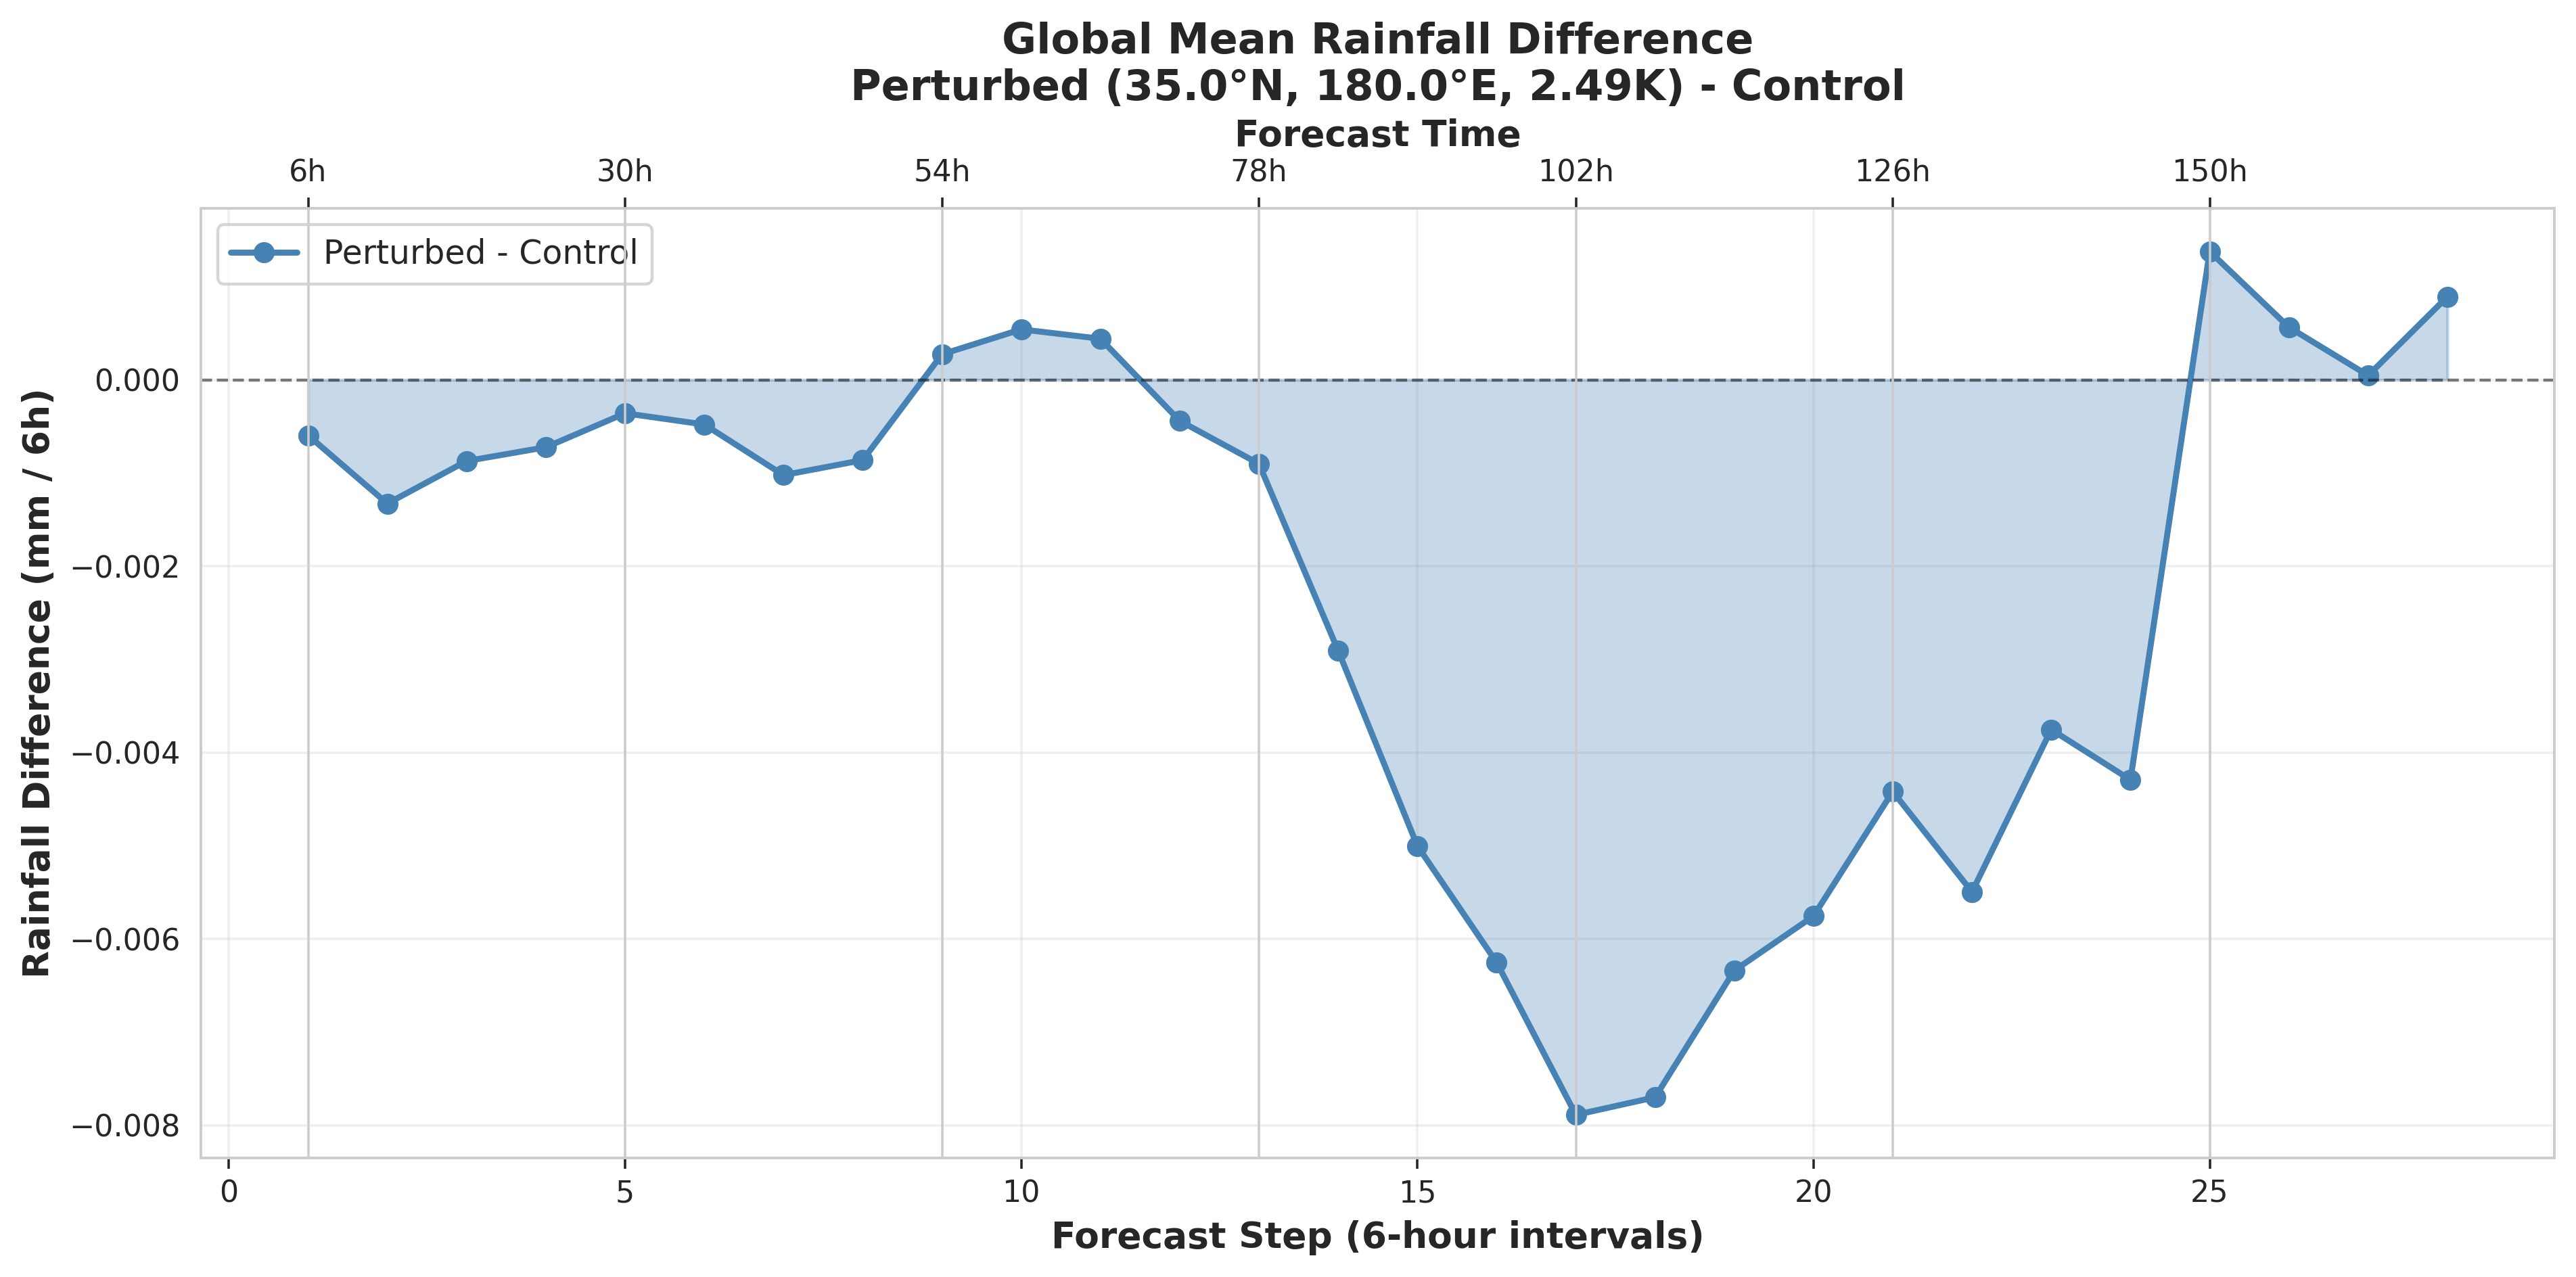


Rainfall difference statistics:
  Mean difference: -0.002259 mm/6h
  Max difference: 0.001378 mm/6h at step 25
  Min difference: -0.007889 mm/6h at step 17


In [ ]:
# Compute global mean rainfall at each time step
control_precip_mean = [np.mean(p) * 1000 for p in control_results['precip']]  # Convert to mm
perturbed_precip_mean = [np.mean(p) * 1000 for p in perturbed_results['precip']]  # Convert to mm

# Compute difference
precip_diff = [perturbed_precip_mean[i] - control_precip_mean[i] for i in range(ROLLOUT_STEPS)]

# Time steps (hours from start)
time_steps = np.arange(1, ROLLOUT_STEPS + 1)
time_hours = time_steps * 6

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(time_steps, precip_diff, 'o-', linewidth=2, markersize=6, color='steelblue', label='Perturbed - Control')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.fill_between(time_steps, 0, precip_diff, alpha=0.3, color='steelblue')

ax.set_xlabel('Forecast Step (6-hour intervals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Rainfall Difference (mm / 6h)', fontsize=12, fontweight='bold')
ax.set_title(f'Global Mean Rainfall Difference\nPerturbed ({PERTURB_LAT}°N, {PERTURB_LON}°E, {amplitude:.2f}K) - Control',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add secondary x-axis for hours
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(time_steps[::4])
ax2.set_xticklabels([f'{h}h' for h in time_hours[::4]])
ax2.set_xlabel('Forecast Time', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rainfall_difference_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nRainfall difference statistics:")
print(f"  Mean difference: {np.mean(precip_diff):.6f} mm/6h")
print(f"  Max difference: {np.max(precip_diff):.6f} mm/6h at step {np.argmax(precip_diff)+1}")
print(f"  Min difference: {np.min(precip_diff):.6f} mm/6h at step {np.argmin(precip_diff)+1}")


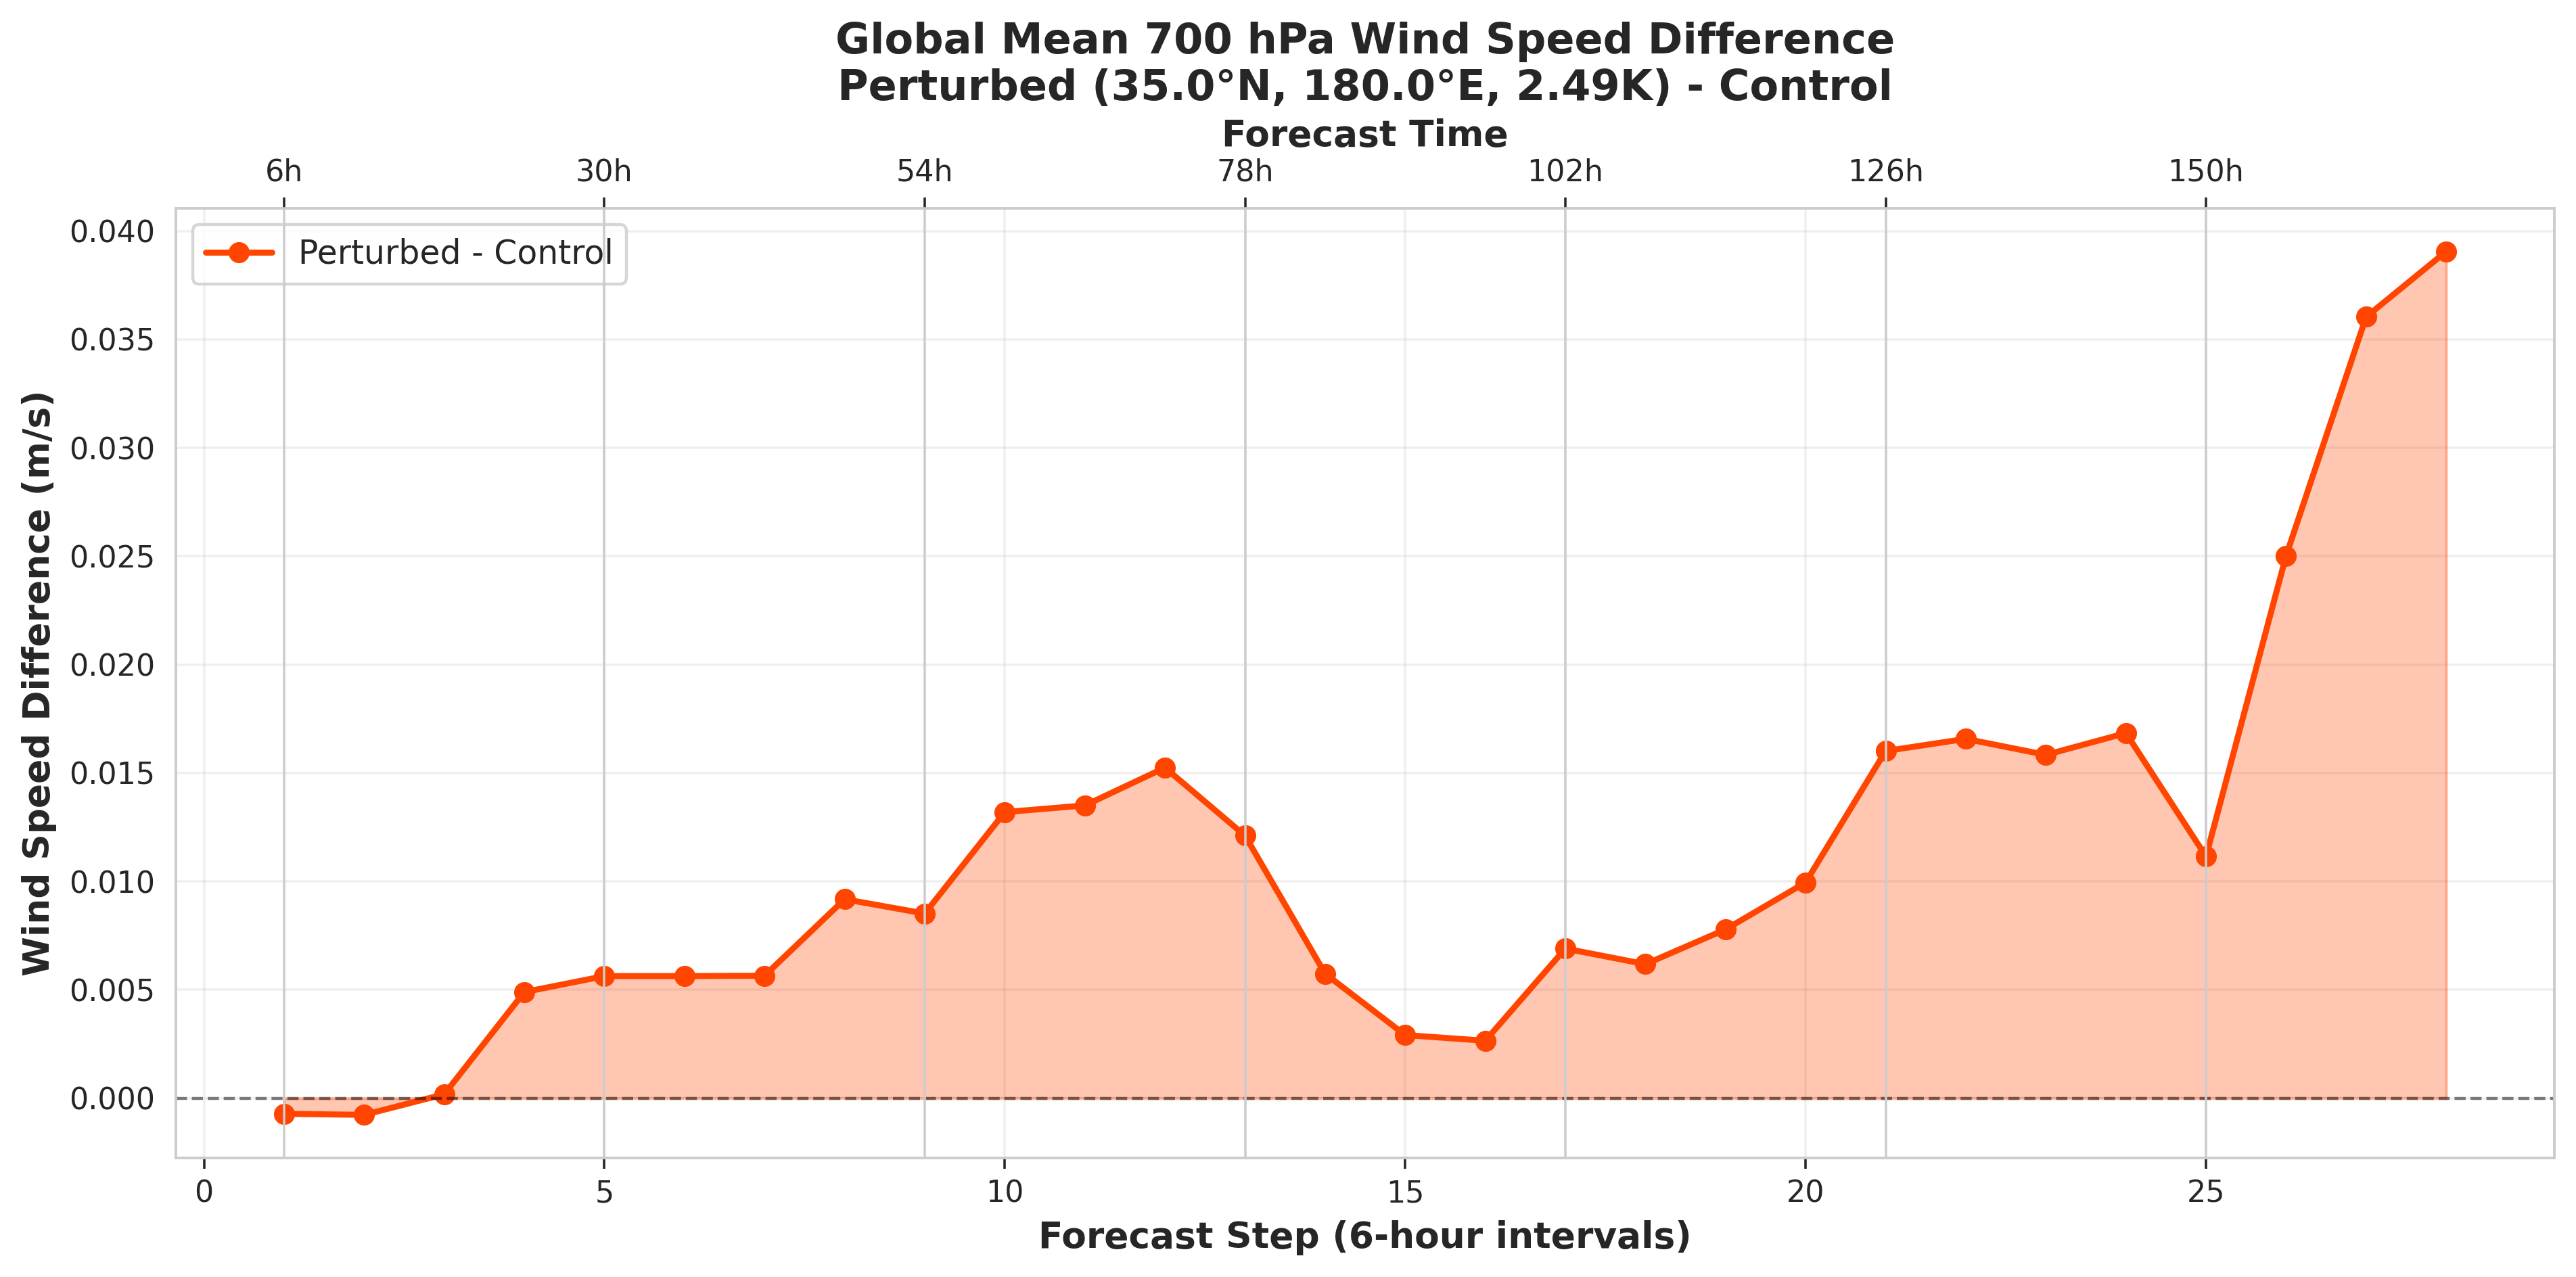


700 hPa wind speed difference statistics:
  Mean difference: 0.011105 m/s
  Max difference: 0.039058 m/s at step 28
  Min difference: -0.000768 m/s at step 2


In [ ]:
# Compute global mean wind speed at 700 hPa at each time step
control_wind_mean = [np.mean(w) for w in control_results['wind_speed_700']]
perturbed_wind_mean = [np.mean(w) for w in perturbed_results['wind_speed_700']]

# Compute difference
wind_diff = [perturbed_wind_mean[i] - control_wind_mean[i] for i in range(ROLLOUT_STEPS)]

# Time steps
time_steps = np.arange(1, ROLLOUT_STEPS + 1)
time_hours = time_steps * 6

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(time_steps, wind_diff, 'o-', linewidth=2, markersize=6, color='orangered', label='Perturbed - Control')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.fill_between(time_steps, 0, wind_diff, alpha=0.3, color='orangered')

ax.set_xlabel('Forecast Step (6-hour intervals)', fontsize=12, fontweight='bold')
ax.set_ylabel('Wind Speed Difference (m/s)', fontsize=12, fontweight='bold')
ax.set_title(f'Global Mean 700 hPa Wind Speed Difference\nPerturbed ({PERTURB_LAT}°N, {PERTURB_LON}°E, {amplitude:.2f}K) - Control',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

# Add secondary x-axis for hours
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(time_steps[::4])
ax2.set_xticklabels([f'{h}h' for h in time_hours[::4]])
ax2.set_xlabel('Forecast Time', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'wind_speed_difference_timeseries.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n700 hPa wind speed difference statistics:")
print(f"  Mean difference: {np.mean(wind_diff):.6f} m/s")
print(f"  Max difference: {np.max(wind_diff):.6f} m/s at step {np.argmax(wind_diff)+1}")
print(f"  Min difference: {np.min(wind_diff):.6f} m/s at step {np.argmin(wind_diff)+1}")


## Direct Comparison: Control vs Perturbed Wind Speed (Single Step)

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


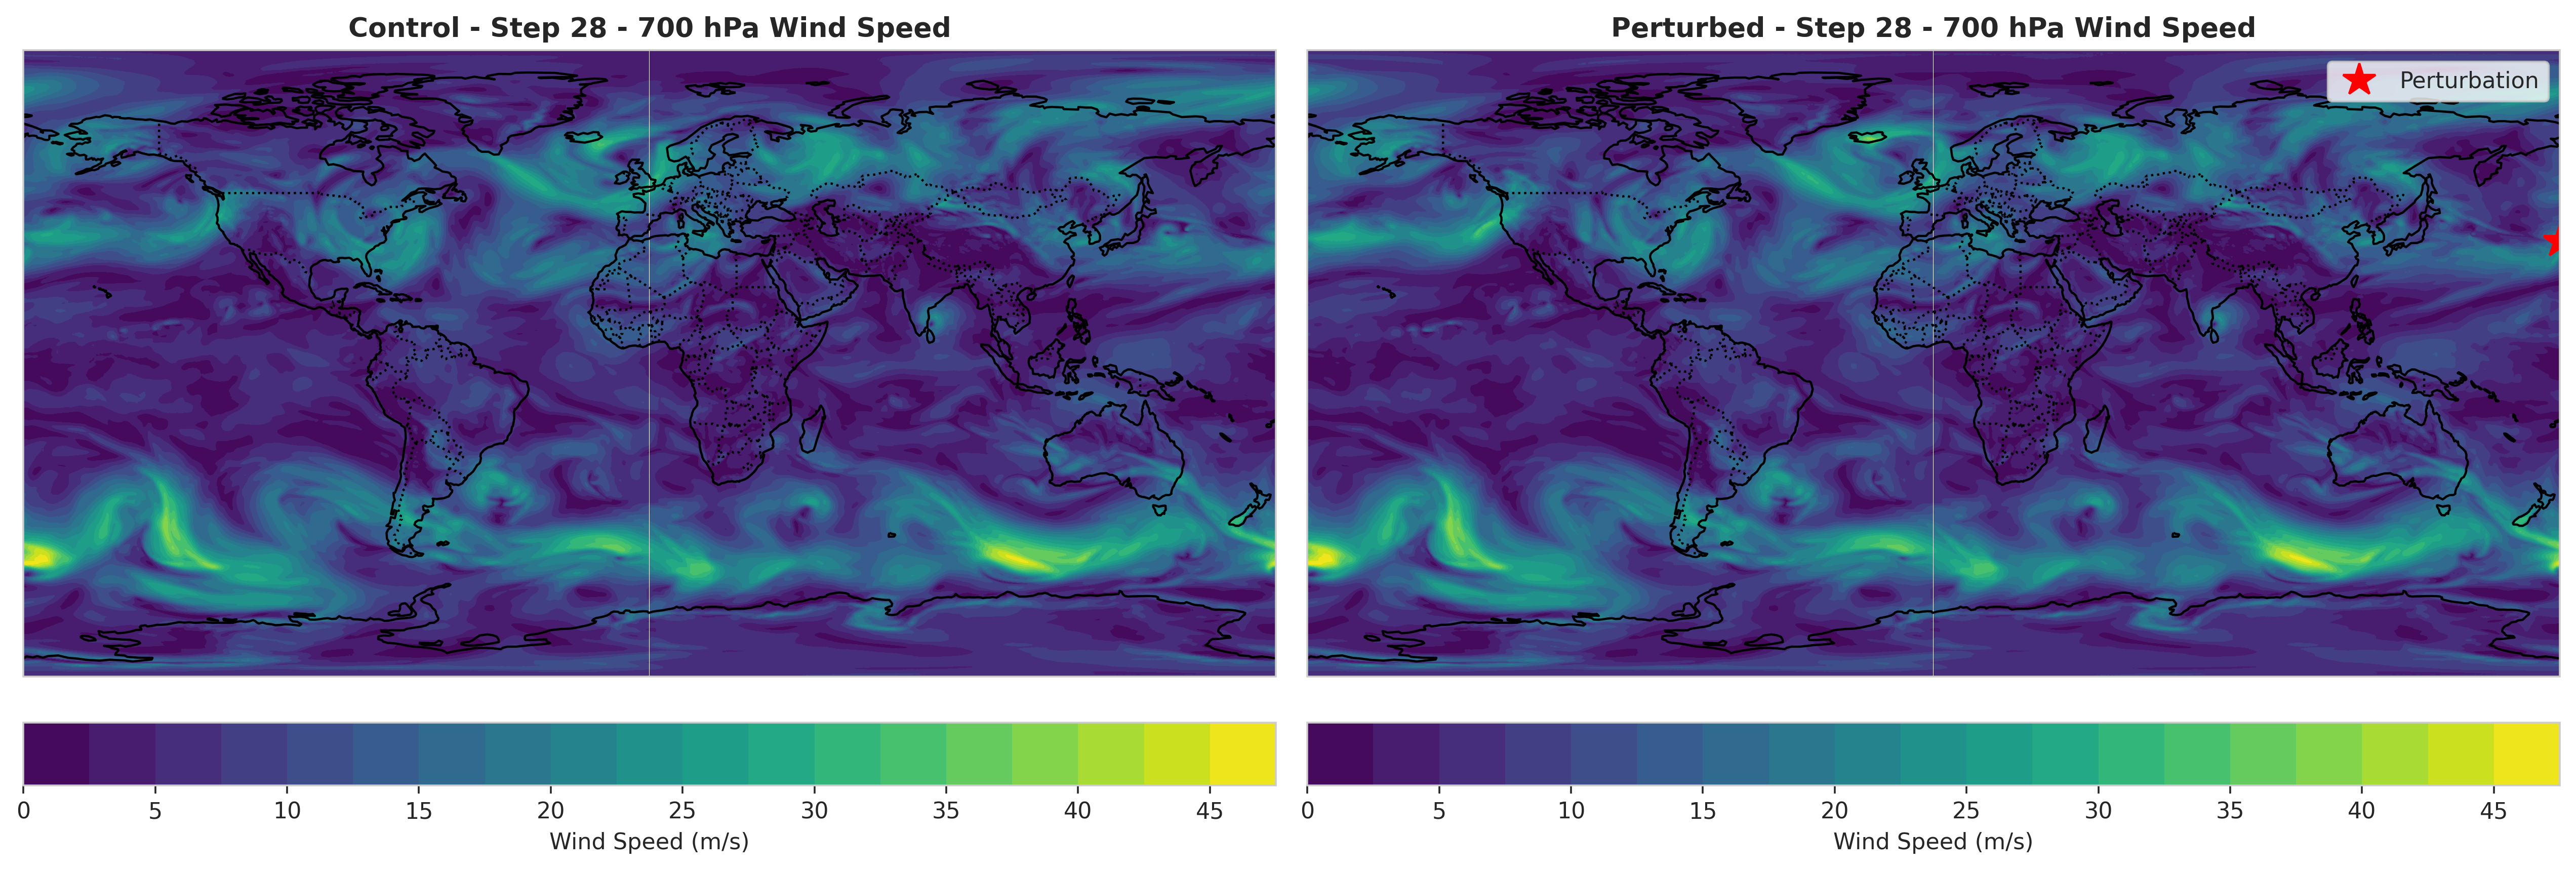


Direct comparison at step 28:
Control - Mean: 9.43 m/s, Max: 46.96 m/s
Perturbed - Mean: 9.47 m/s, Max: 47.25 m/s


In [ ]:
# Direct comparison at a random step (e.g., step 14 - middle of simulation)
import random
step_idx = 27 # Random step between 0-27

fig, axes = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Control simulation
ax1 = axes[0]
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':')
cf1 = ax1.contourf(
    control_results['lon'],
    control_results['lat'],
    control_results['wind_speed_700'][step_idx],
    levels=20,
    cmap='viridis',
    transform=ccrs.PlateCarree()
)
plt.colorbar(cf1, ax=ax1, orientation='horizontal', pad=0.05, label='Wind Speed (m/s)')
ax1.set_title(f'Control - Step {step_idx+1} - 700 hPa Wind Speed', fontsize=12, fontweight='bold')
ax1.set_global()

# Perturbed simulation
ax2 = axes[1]
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':')
cf2 = ax2.contourf(
    perturbed_results['lon'],
    perturbed_results['lat'],
    perturbed_results['wind_speed_700'][step_idx],
    levels=20,
    cmap='viridis',
    transform=ccrs.PlateCarree()
)
plt.colorbar(cf2, ax=ax2, orientation='horizontal', pad=0.05, label='Wind Speed (m/s)')

# Mark perturbation location
ax2.plot(PERTURB_LON, PERTURB_LAT, 'r*', markersize=15, transform=ccrs.PlateCarree(), label='Perturbation')
ax2.legend(loc='upper right')
ax2.set_title(f'Perturbed - Step {step_idx+1} - 700 hPa Wind Speed', fontsize=12, fontweight='bold')
ax2.set_global()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'wind_speed_direct_comparison_step{step_idx+1}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDirect comparison at step {step_idx+1}:")
print(f"Control - Mean: {control_results['wind_speed_700'][step_idx].mean():.2f} m/s, Max: {control_results['wind_speed_700'][step_idx].max():.2f} m/s")
print(f"Perturbed - Mean: {perturbed_results['wind_speed_700'][step_idx].mean():.2f} m/s, Max: {perturbed_results['wind_speed_700'][step_idx].max():.2f} m/s")


In [ ]:
from export_simulation_data import export_both_simulations
export_both_simulations(control_results, perturbed_results,
                        output_dir='exported_data',
                        experiment_name='pacific_perturbation')

✓ Exported to: exported_data/pacific_perturbation_control.npz
  - Precip shape: (28, 720, 1440)
  - Wind shape: (28, 720, 1440)
  - Time steps: 28
✓ Exported to: exported_data/pacific_perturbation_perturbed.npz
  - Precip shape: (28, 720, 1440)
  - Wind shape: (28, 720, 1440)
  - Time steps: 28

✓ Summary saved to: exported_data/pacific_perturbation_summary.json


('exported_data/pacific_perturbation_control.npz',
 'exported_data/pacific_perturbation_perturbed.npz')

In [ ]:
from save_step_figures import save_all_steps, create_comparison_figure

save_all_steps(control_results, 'figures/control', prefix='control',
region='full')
save_all_steps(perturbed_results, 'figures/perturbed',
prefix='perturbed', region='full')


Saving figures to: figures/control
Total steps: 28


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


  Saved step 5/28
  Saved step 10/28
  Saved step 15/28
  Saved step 20/28
  Saved step 25/28
✓ All figures saved! Total: 28 files

Saving figures to: figures/perturbed
Total steps: 28
  Saved step 5/28
  Saved step 10/28
  Saved step 15/28
  Saved step 20/28
  Saved step 25/28
✓ All figures saved! Total: 28 files


['figures/perturbed/perturbed_step_000.png',
 'figures/perturbed/perturbed_step_001.png',
 'figures/perturbed/perturbed_step_002.png',
 'figures/perturbed/perturbed_step_003.png',
 'figures/perturbed/perturbed_step_004.png',
 'figures/perturbed/perturbed_step_005.png',
 'figures/perturbed/perturbed_step_006.png',
 'figures/perturbed/perturbed_step_007.png',
 'figures/perturbed/perturbed_step_008.png',
 'figures/perturbed/perturbed_step_009.png',
 'figures/perturbed/perturbed_step_010.png',
 'figures/perturbed/perturbed_step_011.png',
 'figures/perturbed/perturbed_step_012.png',
 'figures/perturbed/perturbed_step_013.png',
 'figures/perturbed/perturbed_step_014.png',
 'figures/perturbed/perturbed_step_015.png',
 'figures/perturbed/perturbed_step_016.png',
 'figures/perturbed/perturbed_step_017.png',
 'figures/perturbed/perturbed_step_018.png',
 'figures/perturbed/perturbed_step_019.png',
 'figures/perturbed/perturbed_step_020.png',
 'figures/perturbed/perturbed_step_021.png',
 'figures/